# Post 3 - Favorita Demand Data Analysis

First entry point for the Post 3 demand-forecasting analysis. This notebook is intentionally exploratory: it introduces the Favorita panel, shows why the problem is not one generic time series, and previews the dataprep and feature-engineering choices used later by the LightGBM and TabPFN experiments.

What this notebook covers:

- raw CSV inventory and complete panel construction
- train/test calendar coverage and split markers
- family regimes from the PRD: perishable vs non-perishable
- series diversity: scale, intermittency, seasonality, promo exposure
- external signals: oil, transactions, holidays, promotions
- before/after dataprep views for selected series
- feature-engineering snapshots for `minimal`, `lag`, `rolling`, `promo`, and `full`

The notebook uses the same `src/demand` loaders and feature builders as the production experiment notebooks, so the pictures here are also a sanity check on the modeling inputs.

## 0. Control Panel

In [13]:
CONFIG_NAME = "default.yaml"
OUTPUT_SUBDIR = "post3_data_analysis"
SAVE_FIGURES = True

# Keep EDA responsive. These controls only affect visual summaries, not source data.
RANDOM_SEED = 42
FEATURE_ORIGIN = "2017-06-11"       # middle test origin from the PRD
FEATURE_SETS_TO_PREVIEW = ["minimal", "lag", "rolling", "promo", "full"]

# Example series used in the before/after and feature-preview sections.
# Leave as None to auto-pick representative series.
SERIES_EXAMPLES = None
# Example manual override:
# SERIES_EXAMPLES = [(44, "PRODUCE"), (47, "BOOKS"), (1, "CELEBRATION")]

TOP_N_FAMILIES = 12
PLOT_DPI = 140

## 1. Imports and Plot Style

In [23]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
import seaborn as sns

from src.demand.config import load_config, resolve_path
from src.demand.data.features import CATEGORICAL_COLS, build_features, feature_columns
from src.demand.data.load import build_panel, load_raw_data
from src.demand.data.splits import build_core_slice, build_main_splits, family_regime
from src.demand.data.supervised_frame import HISTORICAL_ONLY_COLS, KNOWN_FUTURE_COLS, build_supervised_frame

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(
    context="notebook",
    style="whitegrid",
    rc={
        "figure.dpi": PLOT_DPI,
        "savefig.dpi": PLOT_DPI,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
    },
)
PALETTE = {
    "perishable": "#2A9D8F",
    "non_perishable": "#6C757D",
    "promo": "#E76F51",
    "actual": "#264653",
    "rolling": "#F4A261",
    "oil": "#457B9D",
    "historical": "#264653",
    "known_future": "#E76F51",
}
# Subset used wherever we map a 'regime' hue — keeps seaborn from warning about
# unused palette keys and makes the legend deterministic.
REGIME_PALETTE = {k: PALETTE[k] for k in ("perishable", "non_perishable")}

cfg = load_config(CONFIG_NAME)
splits = build_main_splits(cfg)
feature_origin = pd.Timestamp(FEATURE_ORIGIN)
fig_dir = resolve_path(cfg, "figures_dir") / OUTPUT_SUBDIR
fig_dir.mkdir(parents=True, exist_ok=True)


def savefig(name: str) -> None:
    if SAVE_FIGURES:
        plt.savefig(fig_dir / name, bbox_inches="tight")


def add_split_lines(ax, label_axis: bool = True):
    markers = [
        ("train end", splits.train_end, "#555555", -4, "right"),
        ("val end", splits.val_end, "#777777", -4, "right"),
        ("test start", splits.test_start, "#AA4A44", 4, "left"),
    ]
    for label, date, color, x_offset, ha in markers:
        ax.axvline(pd.Timestamp(date), color=color, linewidth=1.2, linestyle="--", alpha=0.75)
        if label_axis:
            ax.annotate(
                label,
                xy=(pd.Timestamp(date), ax.get_ylim()[1]),
                xytext=(x_offset, -2),
                textcoords="offset points",
                rotation=90,
                va="top",
                ha=ha,
                fontsize=8,
                color=color,
            )

print(f"figures: {fig_dir}")
print(f"feature origin: {feature_origin.date()}")

figures: /Users/alexruppelt/Documents/Projects/tabpfn_analysis/results/figures/post3_data_analysis
feature origin: 2017-06-11


In [24]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    raw = load_raw_data(cfg)
    panel = build_panel(raw, include_test=False)
    panel_with_test = build_panel(raw, include_test=True)

for w in caught:
    print(f"warning: {w.message}")

raw_inventory = pd.DataFrame([
    {"table": "train", "rows": len(raw.train), "columns": raw.train.shape[1], "date_min": raw.train["date"].min(), "date_max": raw.train["date"].max()},
    {"table": "test", "rows": len(raw.test), "columns": raw.test.shape[1], "date_min": raw.test["date"].min(), "date_max": raw.test["date"].max()},
    {"table": "stores", "rows": len(raw.stores), "columns": raw.stores.shape[1], "date_min": pd.NaT, "date_max": pd.NaT},
    {"table": "oil_daily_ffill", "rows": len(raw.oil), "columns": raw.oil.shape[1], "date_min": raw.oil["date"].min(), "date_max": raw.oil["date"].max()},
    {"table": "holidays_events", "rows": len(raw.holidays), "columns": raw.holidays.shape[1], "date_min": raw.holidays["date"].min(), "date_max": raw.holidays["date"].max()},
    {"table": "transactions", "rows": len(raw.transactions), "columns": raw.transactions.shape[1], "date_min": raw.transactions["date"].min(), "date_max": raw.transactions["date"].max()},
])
raw_inventory

,table,rows,columns,date_min,date_max
0,train,3000888,6,2013-01-01,2017-08-15
1,test,28512,5,2017-08-16,2017-08-31
2,stores,54,5,NaT,NaT
3,oil_daily_ffill,1704,2,2013-01-01,2017-08-31
4,holidays_events,350,6,2012-03-02,2017-12-26
5,transactions,83488,3,2013-01-01,2017-08-15


In [25]:
panel_summary = pd.Series({
    "panel_rows_train_only": len(panel),
    "panel_rows_with_test": len(panel_with_test),
    "stores": panel["store_nbr"].nunique(),
    "families": panel["family"].nunique(),
    "series": panel[["store_nbr", "family"]].drop_duplicates().shape[0],
    "date_min": panel["date"].min().date(),
    "date_max": panel["date"].max().date(),
    "test_sales_nan_rows": int(panel_with_test["sales"].isna().sum()),
})
panel_summary.to_frame("value")

,value
panel_rows_train_only,3008016
panel_rows_with_test,3036528
stores,54
families,33
series,1782
date_min,2013-01-01
date_max,2017-08-15
test_sales_nan_rows,28512


In [26]:
panel.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,oil_price,transactions
0,0.000,2013-01-01,1,AUTOMOTIVE,0.000,0,Quito,Pichincha,D,13.000,93.140,NaN
1,"1,782.000",2013-01-02,1,AUTOMOTIVE,2.000,0,Quito,Pichincha,D,13.000,93.140,"2,111.000"
2,"3,564.000",2013-01-03,1,AUTOMOTIVE,3.000,0,Quito,Pichincha,D,13.000,92.970,"1,833.000"
3,"5,346.000",2013-01-04,1,AUTOMOTIVE,3.000,0,Quito,Pichincha,D,13.000,93.120,"1,863.000"
4,"7,128.000",2013-01-05,1,AUTOMOTIVE,5.000,0,Quito,Pichincha,D,13.000,93.120,"1,509.000"


## 3. Calendar Coverage and Demand Scale

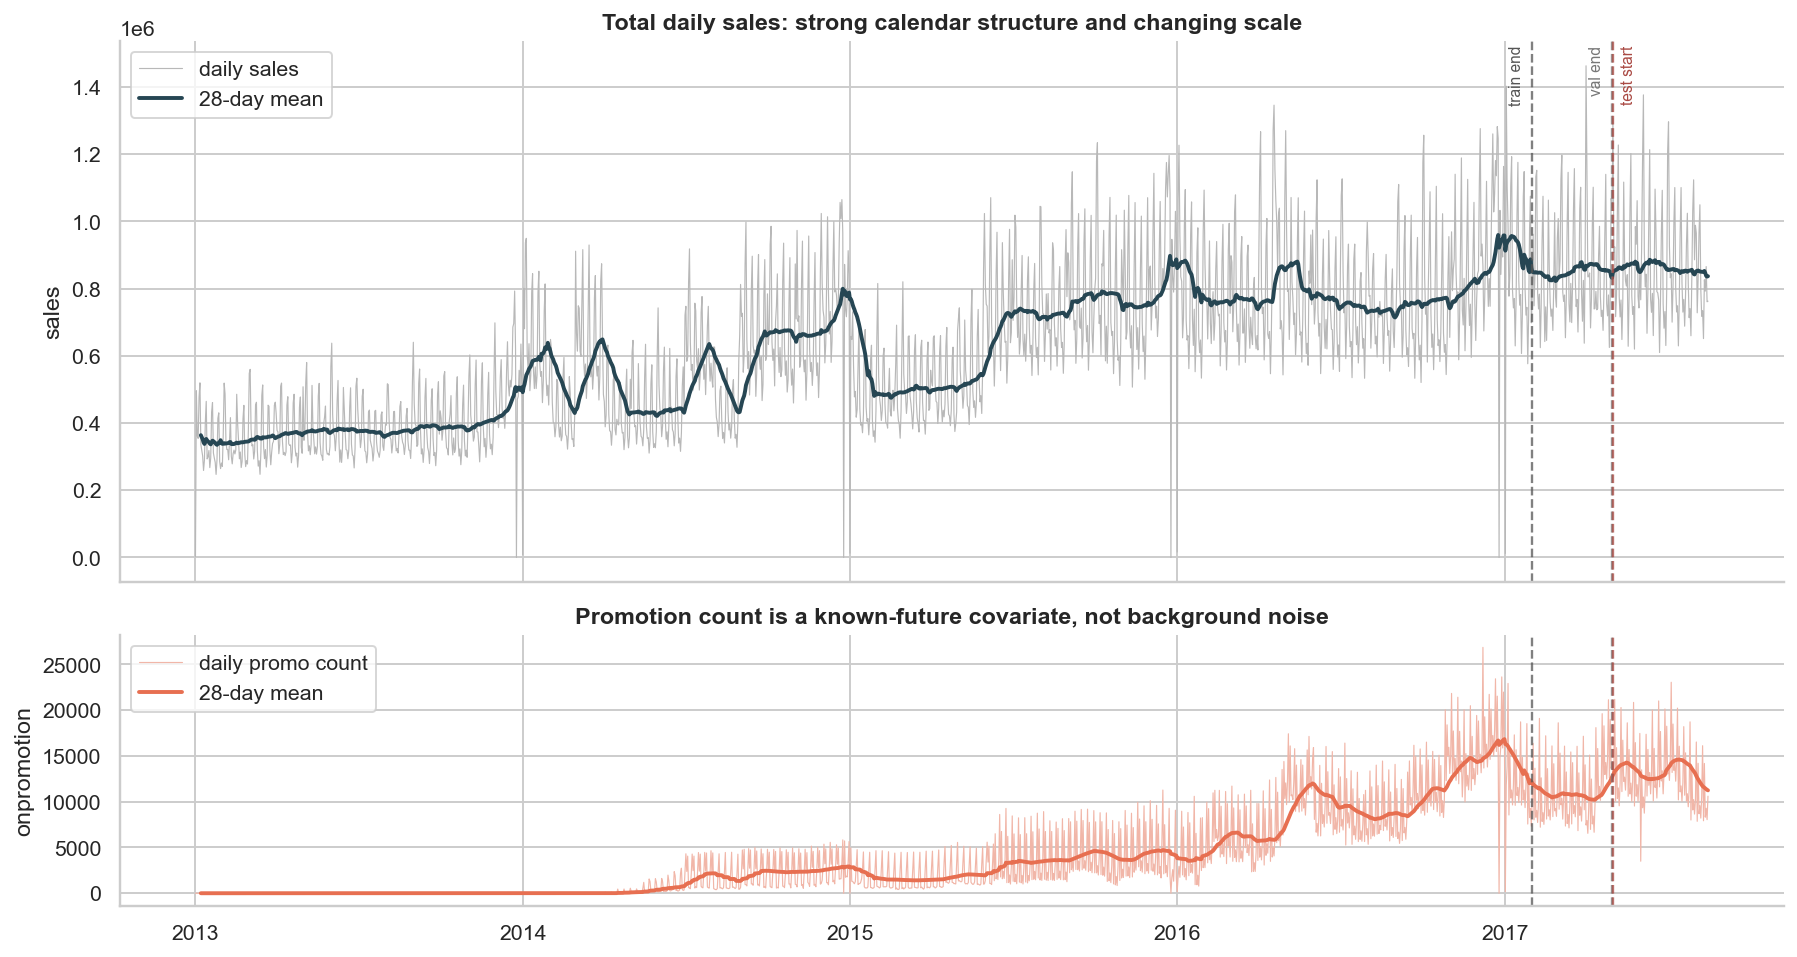

In [18]:
daily = (
    panel.groupby("date", as_index=False)
    .agg(sales=("sales", "sum"), onpromotion=("onpromotion", "sum"), transactions=("transactions", "sum"))
)
daily["sales_ma_28"] = daily["sales"].rolling(28, min_periods=7).mean()
daily["promo_ma_28"] = daily["onpromotion"].rolling(28, min_periods=7).mean()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, height_ratios=[2, 1])
axes[0].plot(daily["date"], daily["sales"], color="#B8B8B8", linewidth=0.6, label="daily sales")
axes[0].plot(daily["date"], daily["sales_ma_28"], color=PALETTE["actual"], linewidth=2, label="28-day mean")
axes[0].set_title("Total daily sales: strong calendar structure and changing scale")
axes[0].set_ylabel("sales")
axes[0].legend(loc="upper left")
add_split_lines(axes[0])

axes[1].plot(daily["date"], daily["onpromotion"], color="#F1B6A8", linewidth=0.6, label="daily promo count")
axes[1].plot(daily["date"], daily["promo_ma_28"], color=PALETTE["promo"], linewidth=2, label="28-day mean")
axes[1].set_title("Promotion count is a known-future covariate, not background noise")
axes[1].set_ylabel("onpromotion")
axes[1].legend(loc="upper left")
# Repeat split lines on the lower axis (without text labels) so the eye can
# trace train/val/test boundaries against promo intensity too.
add_split_lines(axes[1], label_axis=False)
plt.tight_layout()
savefig("01_daily_sales_and_promotions.png")
plt.show()

## 4. Regimes and Family Mix

We evaluate perishable and non-perishable families differently. This view shows why: perishables dominate short-horizon freshness decisions, while many non-perishable families are sparse and promo-sensitive.

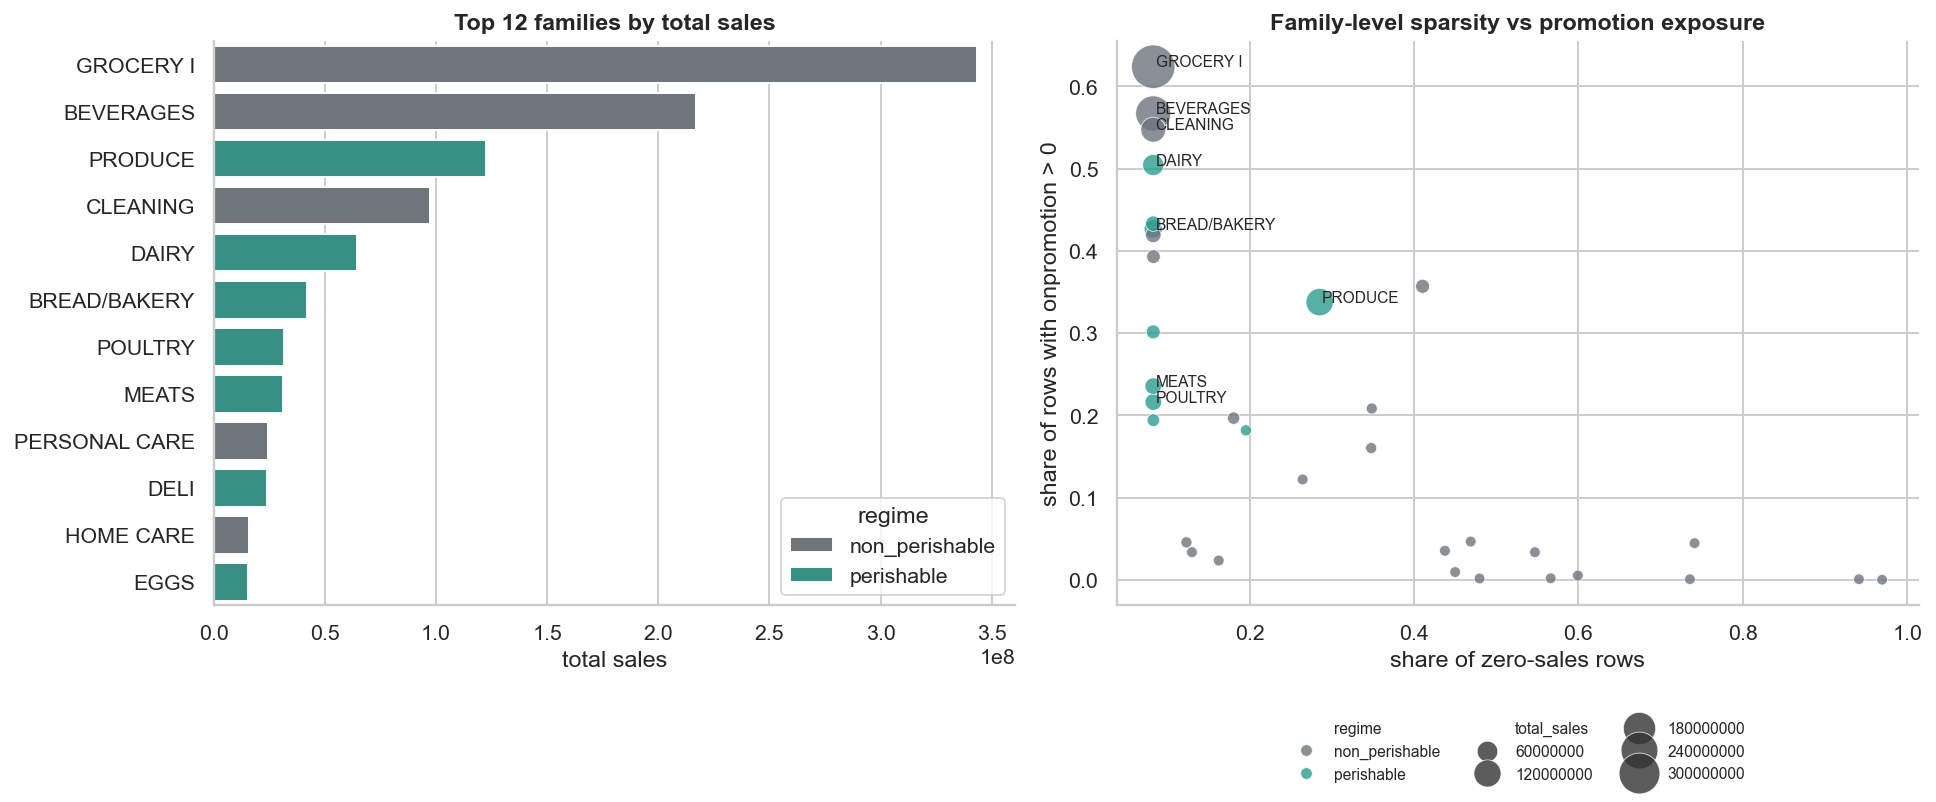

,family,total_sales,mean_sales,zero_share,promo_share,regime
12,GROCERY I,"343,462,734.886","3,768.022",0.083,0.624,non_perishable
3,BEVERAGES,"216,954,486.000","2,380.140",0.083,0.567,non_perishable
30,PRODUCE,"122,704,684.676","1,346.155",0.285,0.338,perishable
7,CLEANING,"97,521,289.000","1,069.875",0.083,0.547,non_perishable
8,DAIRY,"64,487,709.000",707.474,0.083,0.504,perishable
5,BREAD/BAKERY,"42,133,945.576",462.238,0.083,0.427,perishable
28,POULTRY,"31,876,004.472",349.702,0.083,0.216,perishable
24,MEATS,"31,086,468.404",341.040,0.083,0.236,perishable
25,PERSONAL CARE,"24,592,051.000",269.792,0.083,0.419,non_perishable
9,DELI,"24,110,322.469",264.507,0.083,0.433,perishable


In [19]:
family_profile = (
    panel.groupby("family", as_index=False)
    .agg(
        total_sales=("sales", "sum"),
        mean_sales=("sales", "mean"),
        zero_share=("sales", lambda s: float((s == 0).mean())),
        promo_share=("onpromotion", lambda s: float((s > 0).mean())),
    )
)
family_profile["regime"] = family_profile["family"].map(lambda f: family_regime(f, cfg))
family_profile = family_profile.sort_values("total_sales", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top = family_profile.head(TOP_N_FAMILIES).copy()
sns.barplot(data=top, y="family", x="total_sales", hue="regime", palette=REGIME_PALETTE, dodge=False, ax=axes[0])
axes[0].set_title(f"Top {TOP_N_FAMILIES} families by total sales")
axes[0].set_xlabel("total sales")
axes[0].set_ylabel("")
axes[0].legend(title="regime", loc="lower right", frameon=True)

sns.scatterplot(
    data=family_profile,
    x="zero_share",
    y="promo_share",
    hue="regime",
    size="total_sales",
    sizes=(30, 500),
    palette=REGIME_PALETTE,
    alpha=0.8,
    ax=axes[1],
)
for _, r in family_profile.sort_values("total_sales", ascending=False).head(8).iterrows():
    axes[1].text(r["zero_share"] + 0.003, r["promo_share"], r["family"], fontsize=8)
axes[1].set_title("Family-level sparsity vs promotion exposure")
axes[1].set_xlabel("share of zero-sales rows")
axes[1].set_ylabel("share of rows with onpromotion > 0")
# Single legend below the scatter avoids fighting tight_layout when the
# combined hue+size legend grows tall.
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False, fontsize=8)
plt.tight_layout()
savefig("02_family_regimes_and_sparsity.png")
plt.show()

family_profile.head(12)

## 5. Series Diversity: Scale, Intermittency, and Promo Exposure

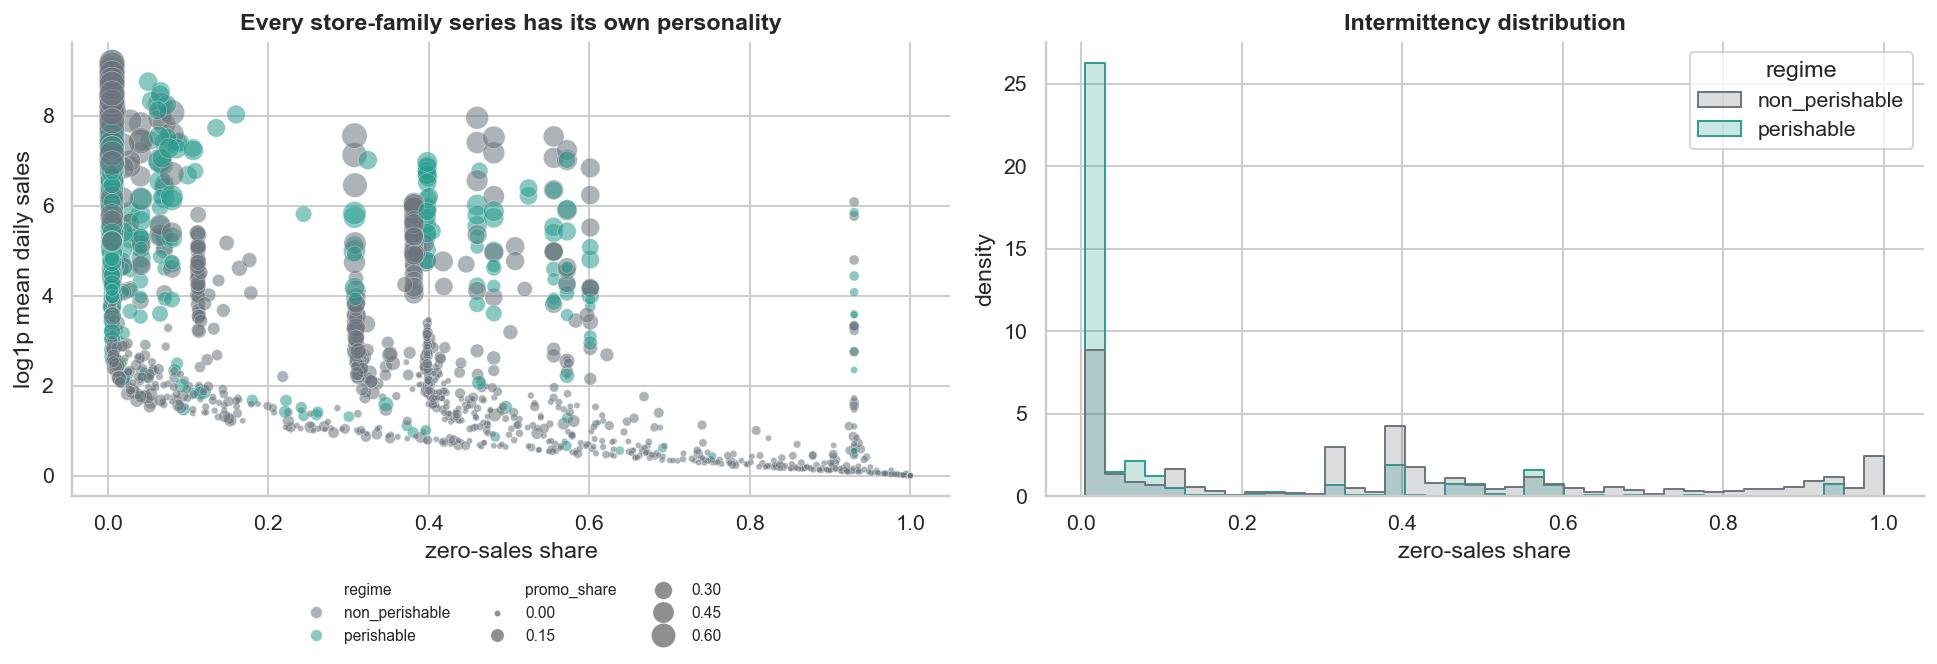

,store_nbr,family,mean_sales,median_sales,total_sales,zero_share,promo_share,active_days,regime,series_id,mean_sales_log1p
1431,44,GROCERY I,"9,707.379","8,798.500","16,386,055.038",0.005,0.671,1679,non_perishable,44__GROCERY I,9.181
1464,45,GROCERY I,"9,685.872","8,964.000","16,349,751.291",0.005,0.674,1679,non_perishable,45__GROCERY I,9.179
1530,47,GROCERY I,"9,191.071","8,525.000","15,514,528.490",0.005,0.672,1679,non_perishable,47__GROCERY I,9.126
1497,46,GROCERY I,"8,496.601","7,323.500","14,342,262.000",0.005,0.669,1679,non_perishable,46__GROCERY I,9.048
1422,44,BEVERAGES,"7,948.969","7,569.500","13,417,859.000",0.005,0.633,1679,non_perishable,44__BEVERAGES,8.981
78,3,GROCERY I,"7,683.927","7,256.000","12,970,467.971",0.005,0.697,1679,non_perishable,3__GROCERY I,8.947
1563,48,GROCERY I,"7,601.300","6,440.500","12,830,994.111",0.005,0.678,1679,non_perishable,48__GROCERY I,8.936
1455,45,BEVERAGES,"6,735.991","6,238.000","11,370,352.000",0.005,0.632,1679,non_perishable,45__BEVERAGES,8.815
69,3,BEVERAGES,"6,724.875","6,548.500","11,351,589.000",0.005,0.666,1679,non_perishable,3__BEVERAGES,8.814
1596,49,GROCERY I,"6,568.709","6,298.000","11,087,980.000",0.005,0.671,1679,non_perishable,49__GROCERY I,8.790


In [20]:
series_profile = (
    panel.groupby(["store_nbr", "family"], as_index=False)
    .agg(
        mean_sales=("sales", "mean"),
        median_sales=("sales", "median"),
        total_sales=("sales", "sum"),
        zero_share=("sales", lambda s: float((s == 0).mean())),
        promo_share=("onpromotion", lambda s: float((s > 0).mean())),
        active_days=("sales", lambda s: int((s > 0).sum())),
    )
)
series_profile["regime"] = series_profile["family"].map(lambda f: family_regime(f, cfg))
series_profile["series_id"] = series_profile["store_nbr"].astype(str) + "__" + series_profile["family"]
series_profile["mean_sales_log1p"] = np.log1p(series_profile["mean_sales"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(
    data=series_profile,
    x="zero_share",
    y="mean_sales_log1p",
    hue="regime",
    size="promo_share",
    sizes=(10, 180),
    palette=REGIME_PALETTE,
    alpha=0.55,
    ax=axes[0],
)
axes[0].set_title("Every store-family series has its own personality")
axes[0].set_xlabel("zero-sales share")
axes[0].set_ylabel("log1p mean daily sales")
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3, frameon=False, fontsize=8)

sns.histplot(
    data=series_profile, x="zero_share", hue="regime", palette=REGIME_PALETTE,
    bins=40, element="step", stat="density", common_norm=False, ax=axes[1],
)
axes[1].set_title("Intermittency distribution")
axes[1].set_xlabel("zero-sales share")
axes[1].set_ylabel("density")
plt.tight_layout()
savefig("03_series_scale_and_intermittency.png")
plt.show()

series_profile.sort_values("total_sales", ascending=False).head(10)

## 6. Store and Cluster Structure

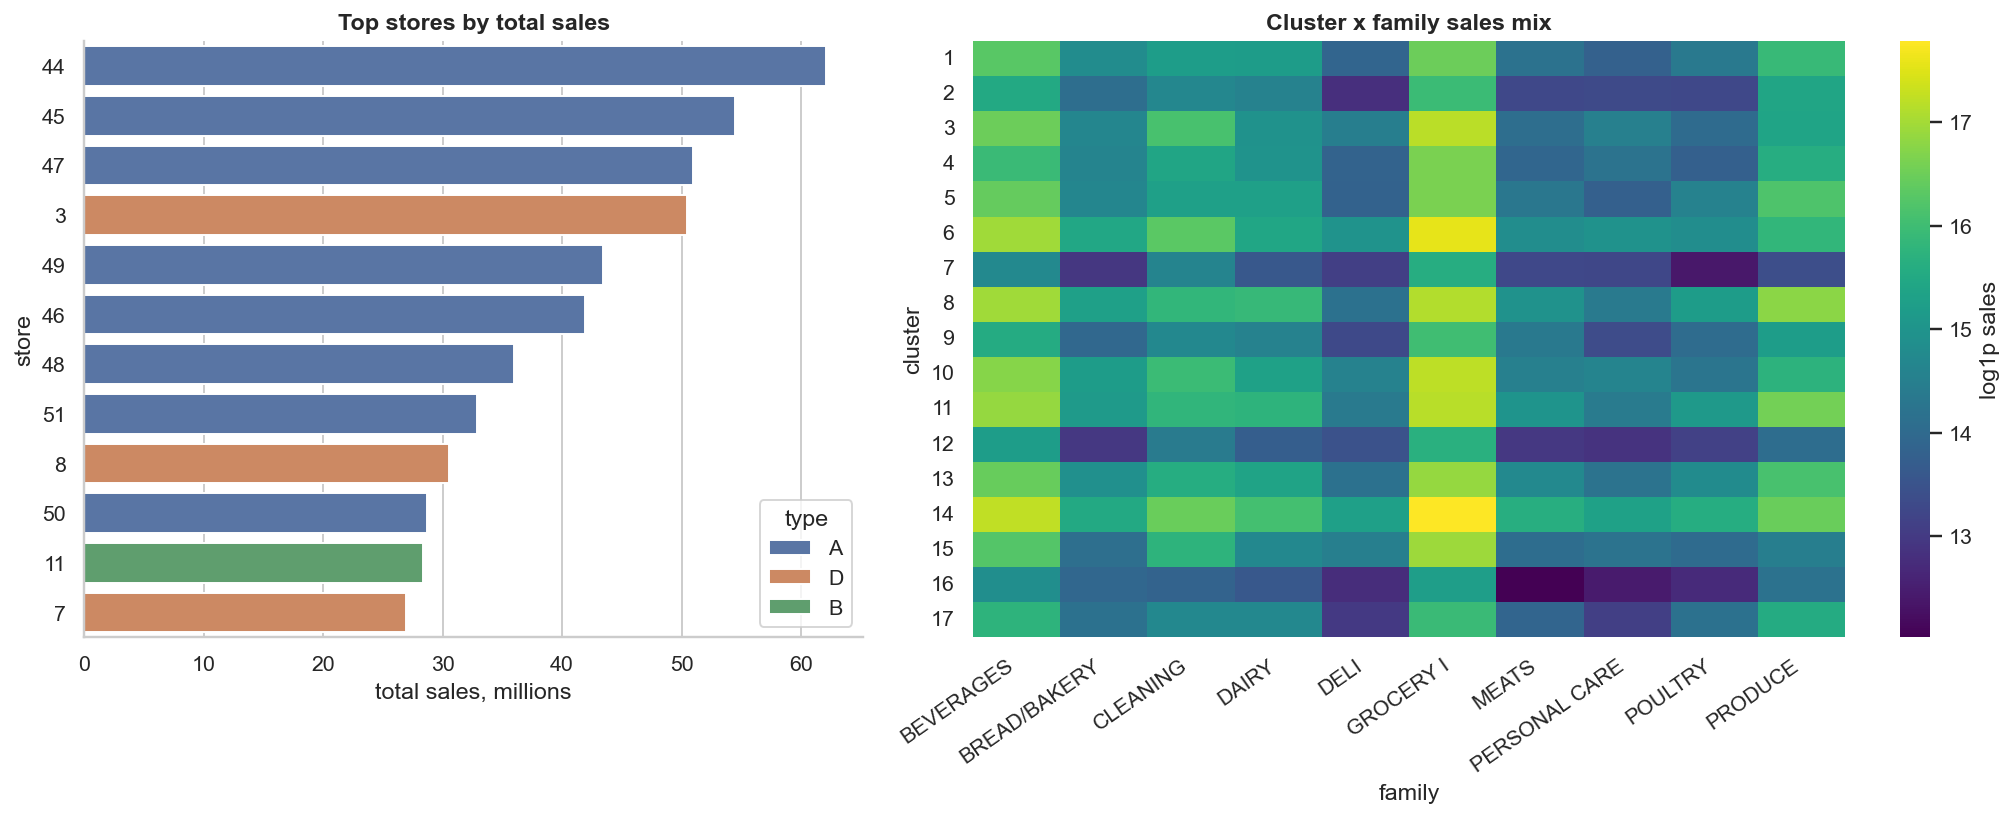

,store_nbr,city,state,type,cluster,total_sales,mean_sales,transactions
43,44,Quito,Pichincha,A,5.000,"62,087,553.250","1,114.598","240,012,069.000"
44,45,Quito,Pichincha,A,11.000,"54,498,010.417",978.350,"204,636,795.000"
46,47,Quito,Pichincha,A,14.000,"50,948,310.061",914.626,"215,681,730.000"
2,3,Quito,Pichincha,D,8.000,"50,481,910.185",906.253,"177,089,550.000"
48,49,Quito,Pichincha,A,11.000,"43,420,095.784",779.479,"150,945,399.000"
45,46,Quito,Pichincha,A,14.000,"41,896,062.122",752.119,"197,673,729.000"
47,48,Quito,Pichincha,A,14.000,"35,933,130.274",645.073,"168,556,905.000"
50,51,Guayaquil,Guayas,A,17.000,"32,911,489.538",590.828,"94,829,262.000"
7,8,Quito,Pichincha,D,8.000,"30,494,286.928",547.434,"153,053,043.000"
49,50,Ambato,Tungurahua,A,14.000,"28,653,020.625",514.380,"144,686,652.000"


In [29]:
store_profile = (
    panel.groupby(["store_nbr", "city", "state", "type", "cluster"], as_index=False)
    .agg(total_sales=("sales", "sum"), mean_sales=("sales", "mean"), transactions=("transactions", "sum"))
    .sort_values("total_sales", ascending=False)
)

# build_panel already merges store metadata, so panel.cluster is authoritative.
cluster_family = panel.assign(cluster=lambda d: d["cluster"].astype(int)).groupby(["cluster", "family"], as_index=False)["sales"].sum()
top_families = family_profile.head(10)["family"].tolist()
heat = (
    cluster_family[cluster_family["family"].isin(top_families)]
    .pivot_table(index="cluster", columns="family", values="sales", aggfunc="sum", fill_value=0)
)
heat = np.log1p(heat)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1, 1.4]})
top_stores = store_profile.head(12).copy()
# Cast to string so seaborn renders store_nbr as a categorical y-axis instead of
# a numeric one (which silently breaks bar order and tick labels).
top_stores["store_label"] = top_stores["store_nbr"].astype(str)
sns.barplot(data=top_stores, y="store_label", x="total_sales", hue="type", dodge=False, ax=axes[0])
axes[0].set_title("Top stores by total sales")
axes[0].set_ylabel("store")
axes[0].set_xlabel("total sales, millions")
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x / 1e6:.0f}"))
axes[0].legend(title="type", loc="lower right")

sns.heatmap(heat, cmap="viridis", ax=axes[1], cbar_kws={"label": "log1p sales"})
axes[1].set_title("Cluster x family sales mix")
axes[1].set_xlabel("family")
axes[1].set_ylabel("cluster")
axes[1].set_yticklabels([str(int(t)) for t in heat.index], rotation=0)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha="right")
plt.tight_layout()
savefig("04_store_cluster_family_mix.png")
plt.show()

store_profile.head(12)

## 7. External Signals: Oil, Transactions, and Holidays

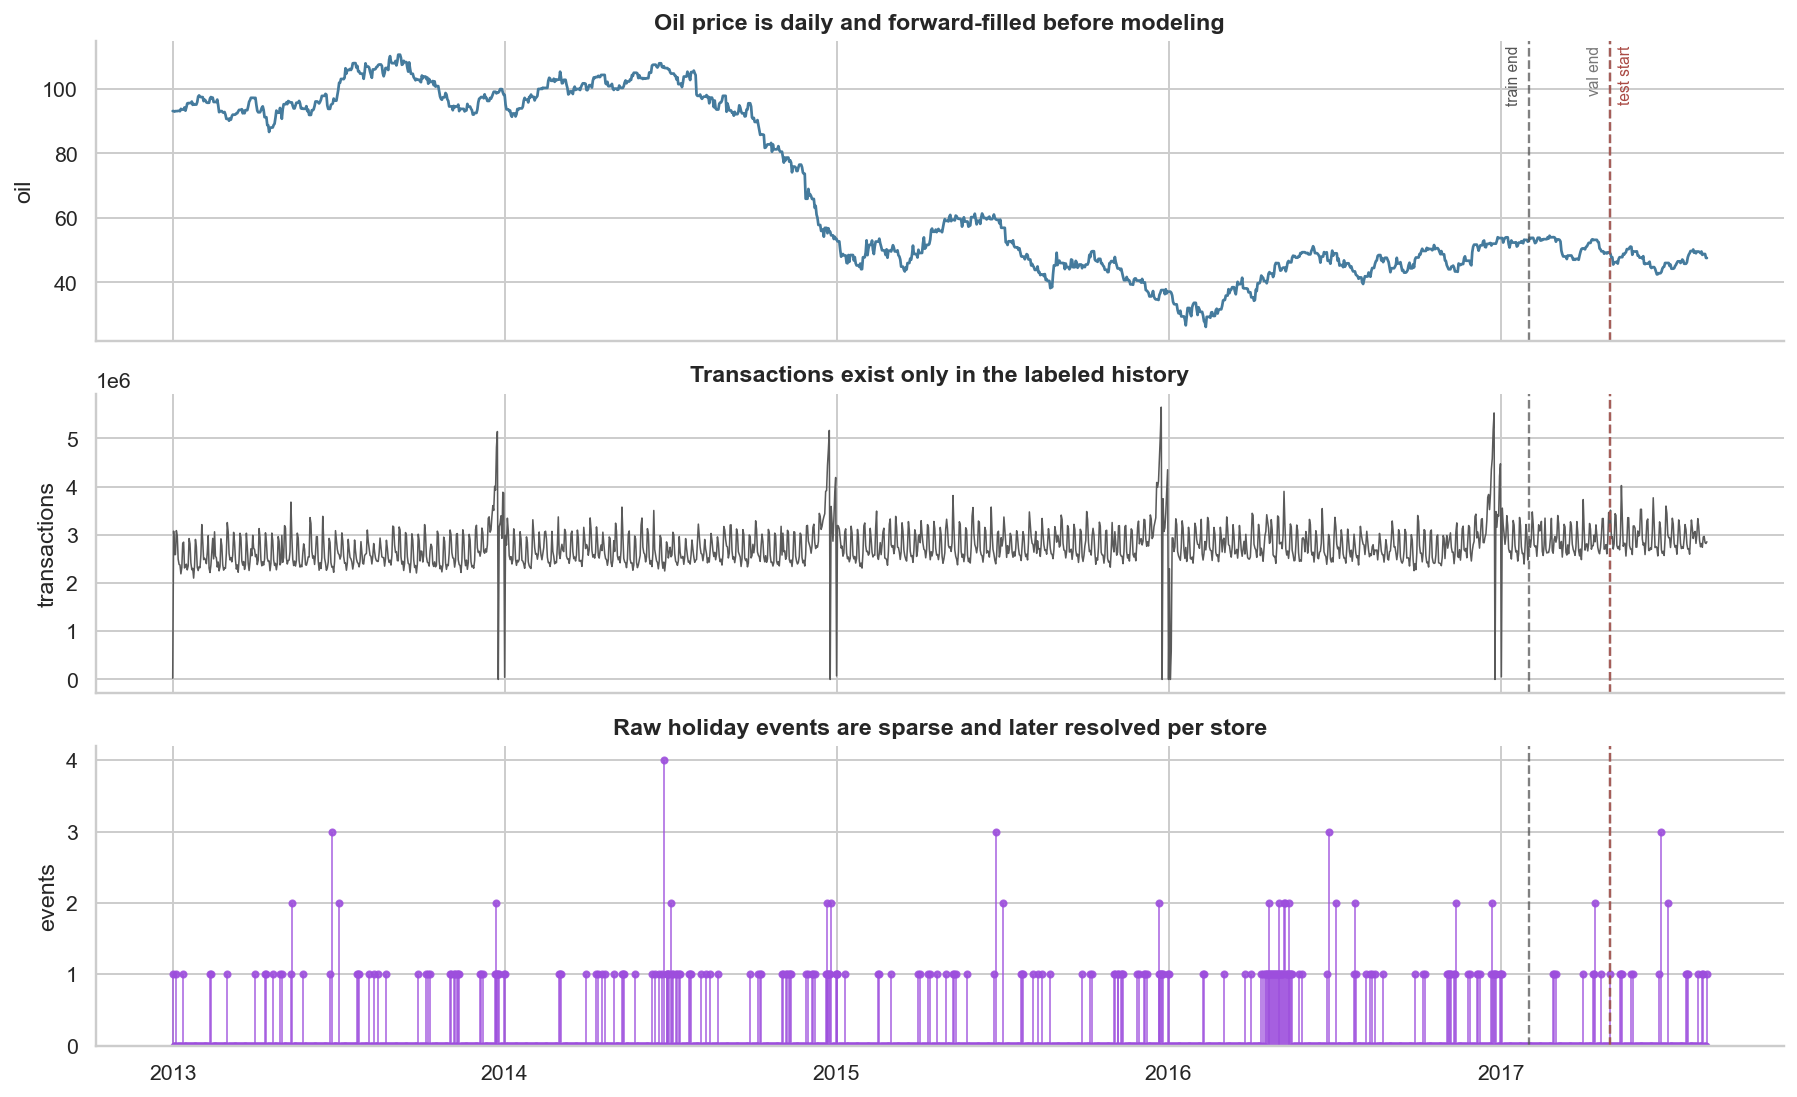

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
5,2012-05-12,Holiday,Local,Puyo,Cantonizacion del Puyo,False
6,2012-06-23,Holiday,Local,Guaranda,Cantonizacion de Guaranda,False
7,2012-06-25,Holiday,Regional,Imbabura,Provincializacion de Imbabura,False
8,2012-06-25,Holiday,Local,Latacunga,Cantonizacion de Latacunga,False
9,2012-06-25,Holiday,Local,Machala,Fundacion de Machala,False


In [30]:
holidays_daily = (
    raw.holidays.assign(transferred=lambda d: d["transferred"].fillna(False).astype(bool))
    .groupby("date", as_index=False)
    .agg(holiday_events=("type", "count"), transferred=("transferred", "sum"))
)
ext = daily.merge(raw.oil.rename(columns={"dcoilwtico": "oil_price"}), on="date", how="left").merge(holidays_daily, on="date", how="left")
ext[["holiday_events", "transferred"]] = ext[["holiday_events", "transferred"]].fillna(0)

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
axes[0].plot(ext["date"], ext["oil_price"], color=PALETTE["oil"], linewidth=1.4)
axes[0].set_title("Oil price is daily and forward-filled before modeling")
axes[0].set_ylabel("oil")

axes[1].plot(ext["date"], ext["transactions"], color="#5A5A5A", linewidth=0.8)
axes[1].set_title("Transactions exist only in the labeled history")
axes[1].set_ylabel("transactions")

# Use stem-style markers for sparse holiday events: a width=1.0 bar with a
# tall y-range visually exaggerates single-day spikes.
axes[2].vlines(ext["date"], 0, ext["holiday_events"], color="#9D4EDD", alpha=0.7, linewidth=1.0)
axes[2].scatter(ext["date"], ext["holiday_events"], color="#9D4EDD", s=10, alpha=0.85)
axes[2].set_title("Raw holiday events are sparse and later resolved per store")
axes[2].set_ylabel("events")
axes[2].set_ylim(bottom=0)

# All three axes share the date axis — mark splits on each so the visual
# story (oil shock, transaction history end, holiday density) lines up.
add_split_lines(axes[0])
add_split_lines(axes[1], label_axis=False)
add_split_lines(axes[2], label_axis=False)
plt.tight_layout()
savefig("05_external_signals.png")
plt.show()

raw.holidays.head(10)

## 8. Pick Example Series

The examples are chosen to show different modeling cases: high-volume perishable, sparse family, and promo-visible non-perishable. Override `SERIES_EXAMPLES` in the control panel if you want a different tour.

In [31]:
if SERIES_EXAMPLES is None:
    examples = []
    # High-volume perishable.
    perishable = series_profile[series_profile["regime"] == "perishable"].sort_values("total_sales", ascending=False).iloc[0]
    examples.append((int(perishable["store_nbr"]), perishable["family"]))
    # Sparse but non-empty family.
    sparse = series_profile[series_profile["family"].eq("BOOKS")].sort_values("active_days", ascending=False).iloc[0]
    examples.append((int(sparse["store_nbr"]), sparse["family"]))
    # Promo-visible non-perishable.
    promo = series_profile[series_profile["regime"].eq("non_perishable")].sort_values("promo_share", ascending=False).iloc[0]
    examples.append((int(promo["store_nbr"]), promo["family"]))
else:
    examples = SERIES_EXAMPLES

examples_df = pd.DataFrame(examples, columns=["store_nbr", "family"]).merge(series_profile, on=["store_nbr", "family"], how="left")
examples_df

,store_nbr,family,mean_sales,median_sales,total_sales,zero_share,promo_share,active_days,regime,series_id,mean_sales_log1p
0,44,PRODUCE,"6,318.755","7,672.473","10,666,058.478",0.050,0.356,1603,perishable,44__PRODUCE,8.751
1,3,BOOKS,0.320,0.000,540.000,0.893,0.000,181,non_perishable,3__BOOKS,0.278
2,6,GROCERY I,"4,624.790","4,326.500","7,806,646.169",0.005,0.706,1679,non_perishable,6__GROCERY I,8.439


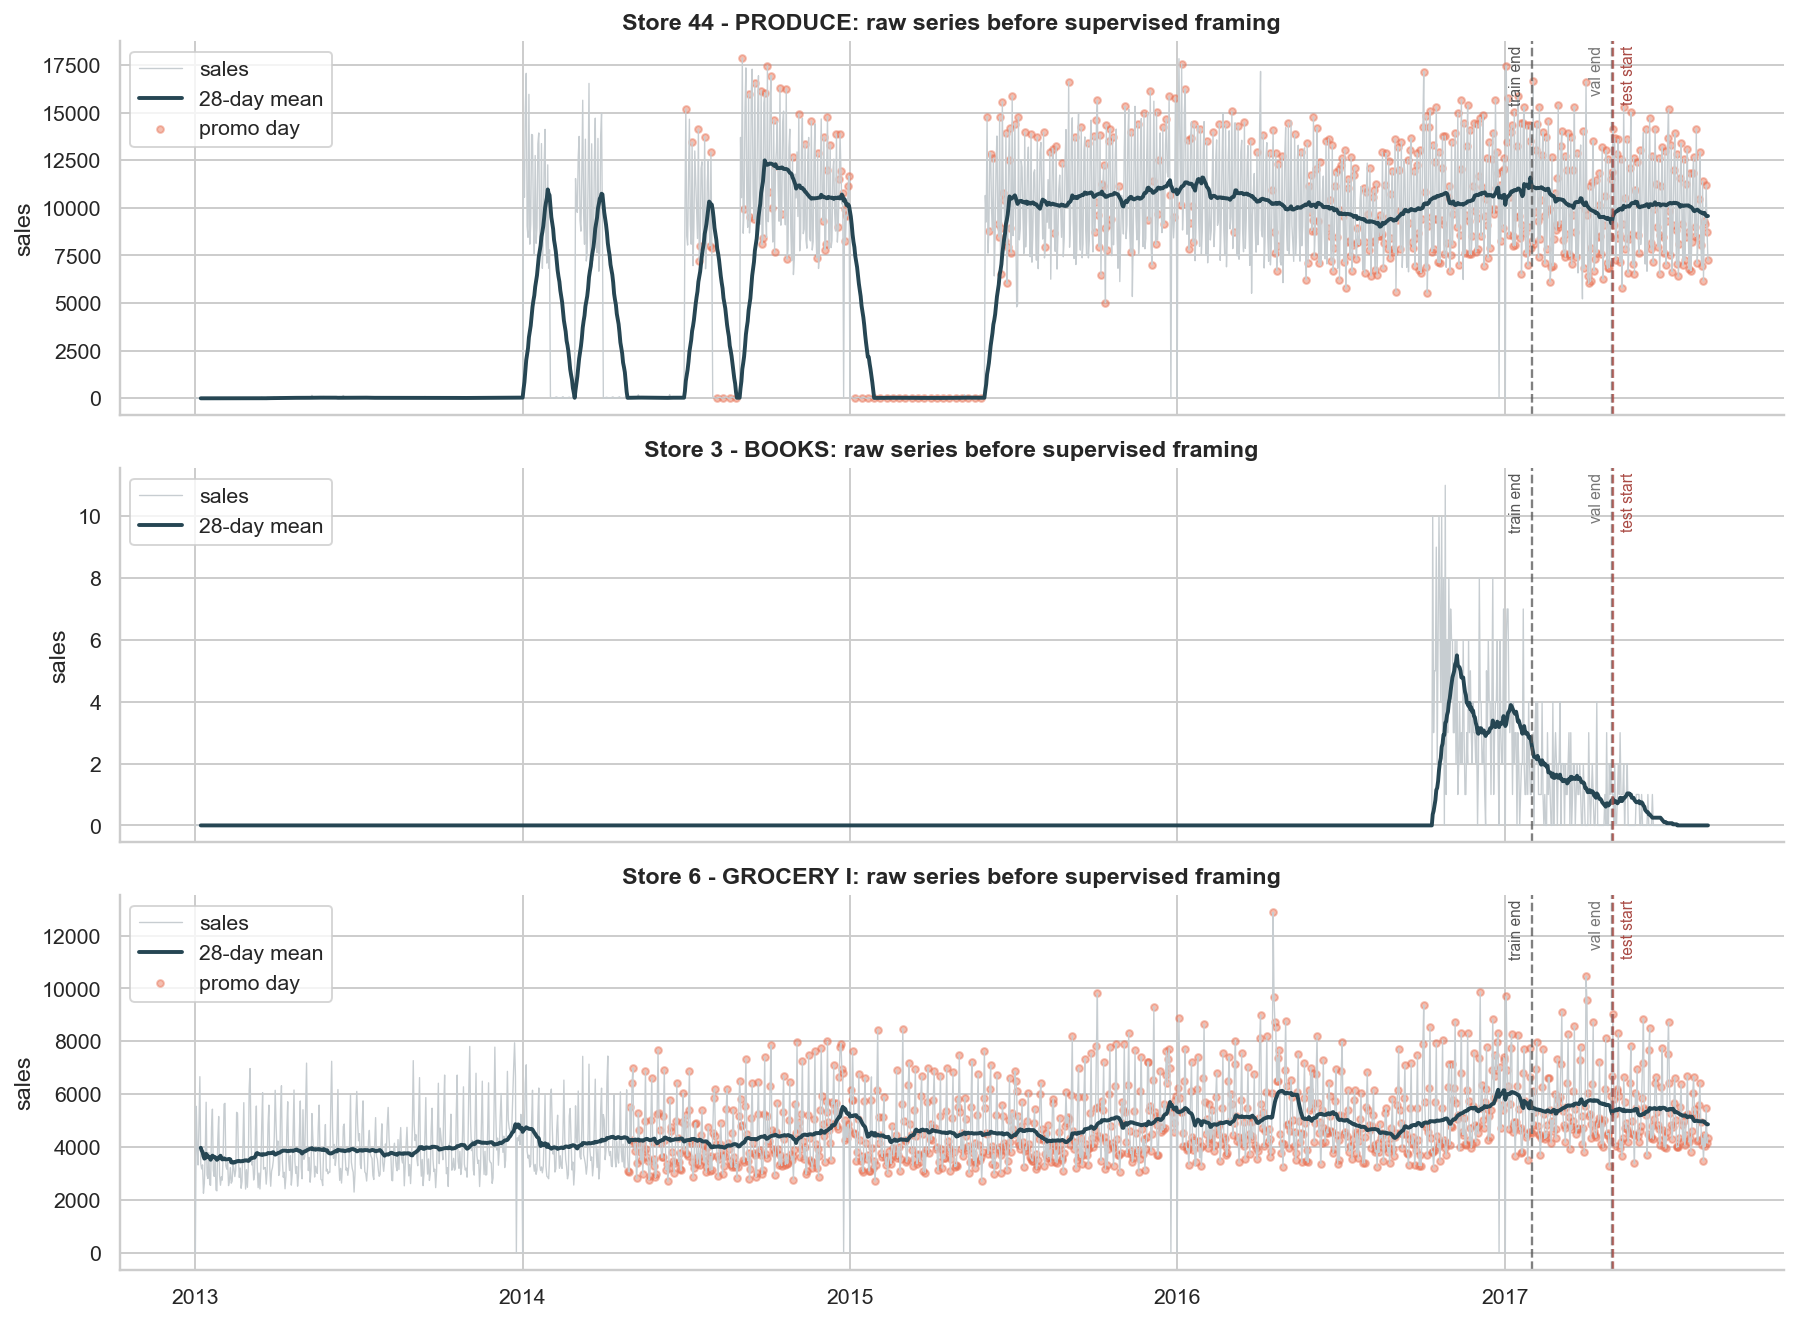

In [32]:
fig, axes = plt.subplots(len(examples), 1, figsize=(13, 3.2 * len(examples)), sharex=True)
if len(examples) == 1:
    axes = [axes]

for ax, (store, fam) in zip(axes, examples):
    s = panel[(panel["store_nbr"] == store) & (panel["family"] == fam)].sort_values("date").copy()
    s["sales_ma_28"] = s["sales"].rolling(28, min_periods=7).mean()
    ax.plot(s["date"], s["sales"], color="#C7CDD1", linewidth=0.7, label="sales")
    ax.plot(s["date"], s["sales_ma_28"], color=PALETTE["actual"], linewidth=2, label="28-day mean")
    promo_days = s[s["onpromotion"] > 0]
    if not promo_days.empty:
        ax.scatter(promo_days["date"], promo_days["sales"], s=12, color=PALETTE["promo"], alpha=0.45, label="promo day")
    ax.set_title(f"Store {store} - {fam}: raw series before supervised framing")
    ax.set_ylabel("sales")
    ax.legend(loc="upper left")
    add_split_lines(ax)
plt.tight_layout()
savefig("06_example_series_raw_and_rolling.png")
plt.show()

## 9. Before and After Panel Dataprep

The raw train file has missing panel cells. The modeling panel reindexes to the complete `(date, store, family)` grid and zero-fills train-period sales gaps. This is not feature engineering yet; it is making the grain explicit.

Spoiler for the chart below: the 7,128 missing rows are concentrated on **4 days only** — Christmas Day in 2013, 2014, 2015, and 2016 — when all 1,782 store-family cells are absent because every store was closed. So expect four tall isolated spikes, not a dense distribution.

In [33]:
raw_keys = raw.train[["date", "store_nbr", "family", "sales", "onpromotion"]].copy()
panel_keys = panel[["date", "store_nbr", "family", "sales", "onpromotion"]].copy()
raw_key_set = raw_keys.set_index(["date", "store_nbr", "family"])
panel_key_set = panel_keys.set_index(["date", "store_nbr", "family"])
added_idx = panel_key_set.index.difference(raw_key_set.index)
added = panel_key_set.loc[added_idx].reset_index()

added_summary = pd.Series({
    "raw_train_rows": len(raw.train),
    "complete_panel_rows": len(panel),
    "zero_filled_gap_rows": len(added),
    "gap_sales_sum_after_fill": float(added["sales"].sum()) if len(added) else 0.0,
    "gap_promo_sum_after_fill": int(added["onpromotion"].sum()) if len(added) else 0,
})
added_summary.to_frame("value")

,value
raw_train_rows,"3,000,888.000"
complete_panel_rows,"3,008,016.000"
zero_filled_gap_rows,"7,128.000"
gap_sales_sum_after_fill,0.000
gap_promo_sum_after_fill,0.000


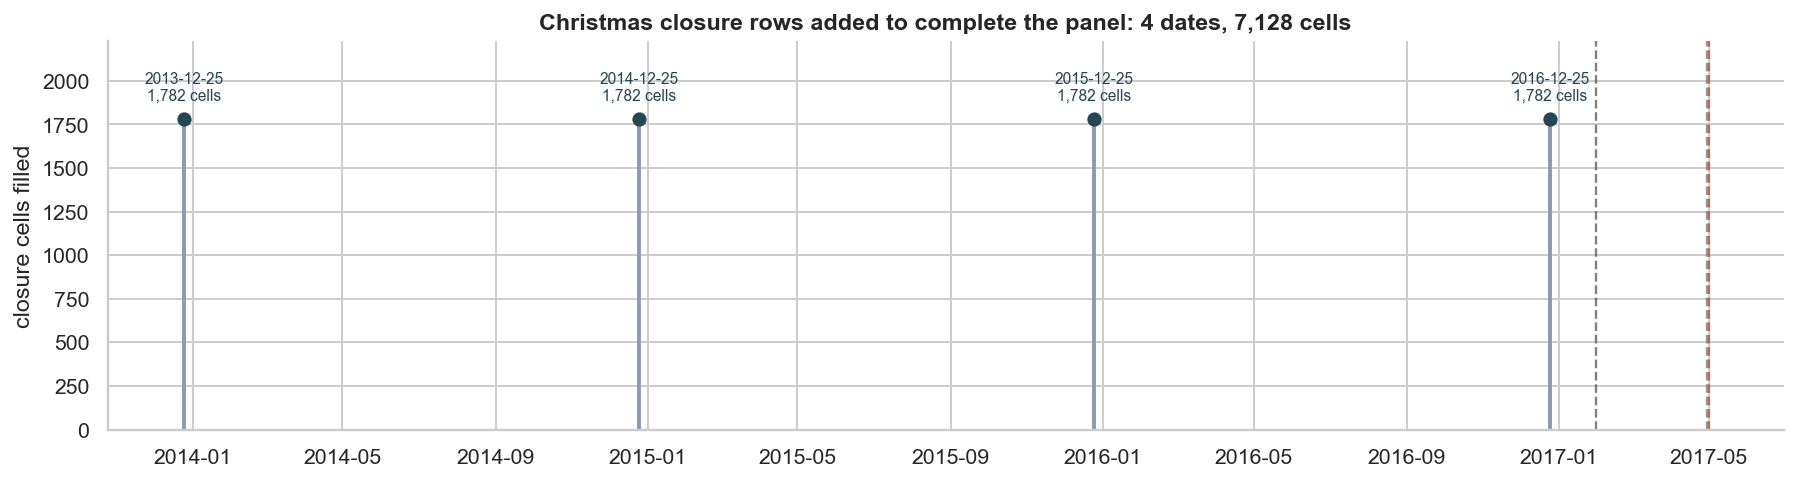

In [34]:
if len(added):
    added_by_date = added.groupby("date", as_index=False).size().sort_values("date")
    fig, ax = plt.subplots(figsize=(13, 3.6))
    # Stems beat bars when only a handful of dates have any gaps — width=1.0
    # bars on a multi-year x-axis would be sub-pixel and disappear.
    ax.vlines(added_by_date["date"], 0, added_by_date["size"], color="#8D99AE", linewidth=2)
    ax.scatter(added_by_date["date"], added_by_date["size"], color="#264653", s=40, zorder=3)
    for _, row in added_by_date.iterrows():
        ax.annotate(
            f"{row['date'].date()}\n{int(row['size']):,} cells",
            xy=(row["date"], row["size"]),
            xytext=(0, 8), textcoords="offset points",
            ha="center", va="bottom", fontsize=8, color="#264653",
        )
    ax.set_ylim(0, added_by_date["size"].max() * 1.25)
    ax.set_title(f"Christmas closure rows added to complete the panel: {added_by_date.shape[0]} dates, {len(added):,} cells")
    ax.set_ylabel("closure cells filled")
    ax.set_xlabel("")
    add_split_lines(ax, label_axis=False)
    plt.tight_layout()
    savefig("07_zero_filled_panel_gaps.png")
    plt.show()
else:
    print("No panel gaps were found.")

## 10. Feature Engineering Preview on the Core Slice

This section repeats the actual feature construction used downstream. The five feature levels are monotonically nested: `minimal` -> `lag` -> `rolling` -> `promo` -> `full`. We build them at one forecast origin and compare feature coverage.

In [35]:
core = build_core_slice(panel, raw.stores, cfg, write_csv=False)
core_panel = panel.merge(core, on=["store_nbr", "family"], how="inner")
print(f"core series: {len(core):,}; families represented: {core['family'].nunique()} / {panel['family'].nunique()}")

feature_frames = {}
coverage_rows = []
for fs in FEATURE_SETS_TO_PREVIEW:
    feats = build_features(
        core_panel,
        feature_set=fs,
        as_of=feature_origin,
        config=cfg,
        holidays=raw.holidays,
        stores=raw.stores,
    )
    feature_frames[fs] = feats
    cols = feature_columns(fs, include_earthquake=True)
    cols = [c for c in cols if c in feats.columns]
    for col in cols:
        coverage_rows.append({
            "feature_set": fs,
            "feature": col,
            "non_null_pct": float(feats[col].notna().mean() * 100),
            "n_unique": int(feats[col].nunique(dropna=True)),
            "dtype": str(feats[col].dtype),
        })
coverage = pd.DataFrame(coverage_rows)
coverage.head(10)

/Users/alexruppelt/Documents/Projects/tabpfn_analysis/src/demand/data/splits.py:205: UserWarning: core-slice: used best-available sparse-family fallback for families ['BOOKS']
  warnings.warn(


core series: 100; families represented: 33 / 33


,feature_set,feature,non_null_pct,n_unique,dtype
0,minimal,day_of_week,100.000,7,int16
1,minimal,day_of_month,100.000,31,int16
2,minimal,month,100.000,12,int16
3,minimal,year,100.000,5,int16
4,minimal,onpromotion,100.000,183,int64
5,minimal,is_holiday,100.000,2,int8
6,minimal,oil_price,100.000,964,float32
7,minimal,store_nbr,100.000,49,int64
8,minimal,family,100.000,33,object
9,minimal,city,100.000,22,object


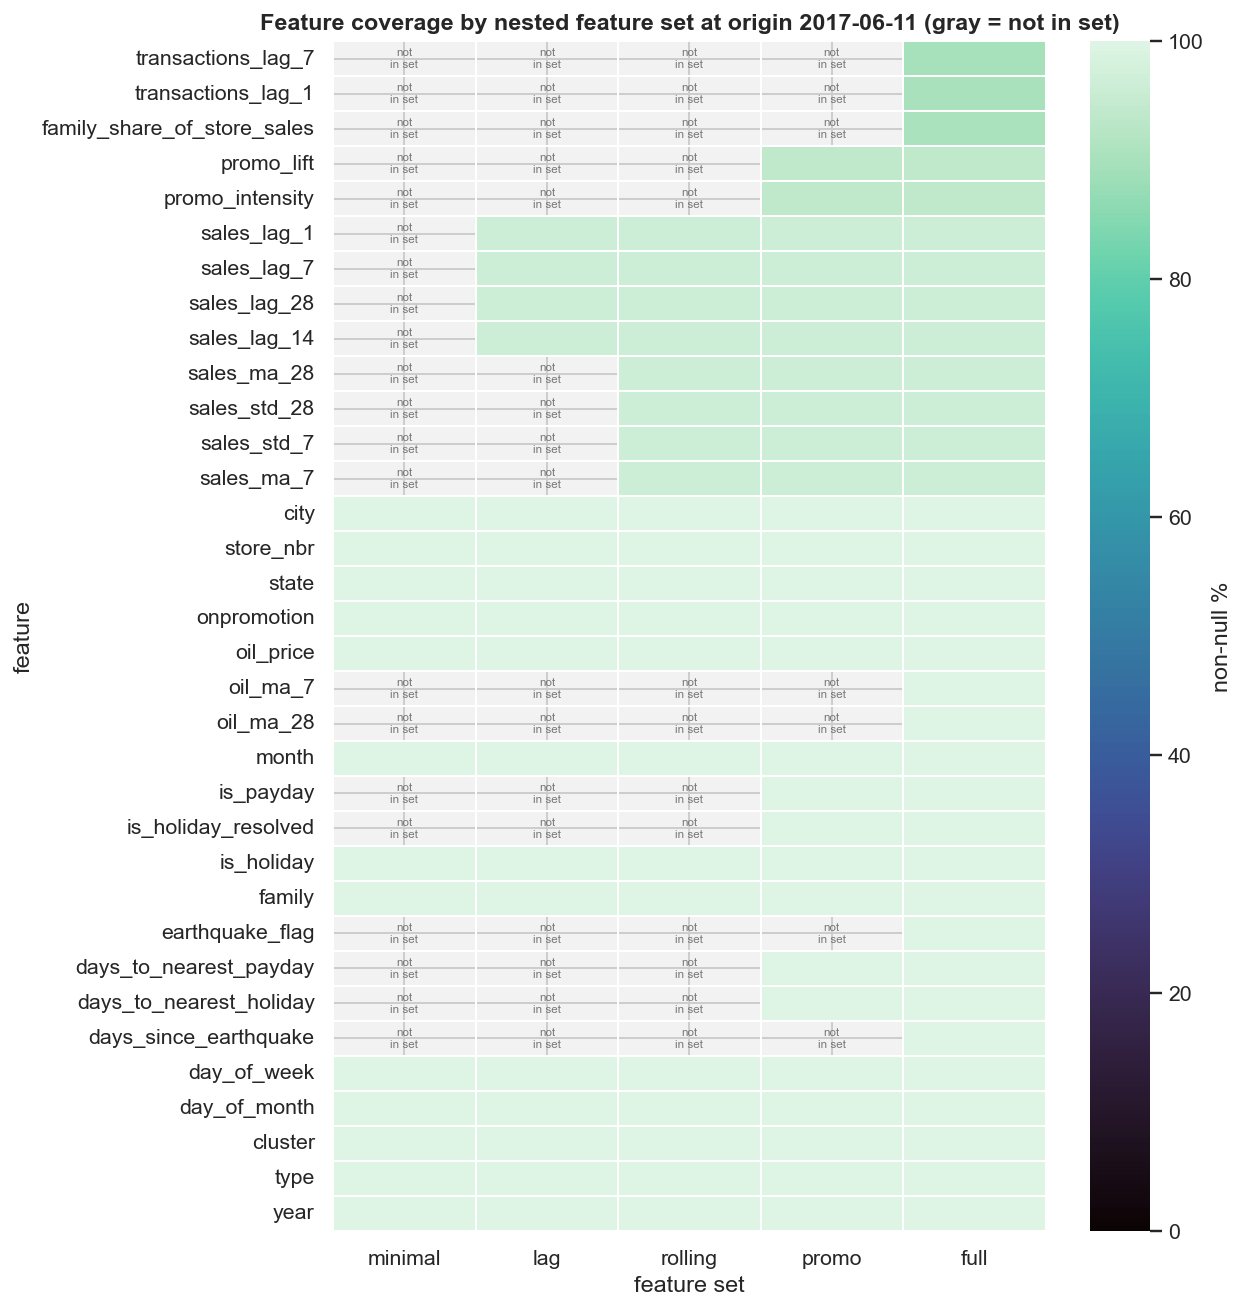

In [36]:
coverage_pivot = coverage.pivot_table(index="feature", columns="feature_set", values="non_null_pct", aggfunc="mean")
coverage_pivot = coverage_pivot.reindex(columns=FEATURE_SETS_TO_PREVIEW)
coverage_pivot = coverage_pivot.sort_values(FEATURE_SETS_TO_PREVIEW[-1])
coverage_mask = coverage_pivot.isna()

fig, ax = plt.subplots(figsize=(9, max(7, 0.28 * len(coverage_pivot))))
ax.set_facecolor("#F2F2F2")
sns.heatmap(
    coverage_pivot,
    mask=coverage_mask,
    cmap="mako",
    vmin=0,
    vmax=100,
    linewidths=0.2,
    linecolor="white",
    cbar_kws={"label": "non-null %"},
    ax=ax,
)
for y, x in zip(*np.where(coverage_mask.values)):
    ax.text(x + 0.5, y + 0.5, "not\nin set", ha="center", va="center", fontsize=6, color="#777777")
ax.set_title(f"Feature coverage by nested feature set at origin {feature_origin.date()} (gray = not in set)")
ax.set_xlabel("feature set")
ax.set_ylabel("feature")
plt.tight_layout()
savefig("08_feature_coverage_by_level.png")
plt.show()

In [45]:
from IPython.display import HTML, display
from src.demand.data.features import build_features, feature_columns

# Pick one series to inspect.
STORE_NBR = 44
FAMILY = "PRODUCE"

AS_OF = feature_origin
DAYS = 30
start_date = AS_OF - pd.Timedelta(days=DAYS - 1)


def unique_cols(cols):
    seen = set()
    out = []
    for c in cols:
        if c not in seen:
            out.append(c)
            seen.add(c)
    return out


def display_scroll(df, height=520):
    html = df.to_html(index=False, max_rows=None)
    display(HTML(f"""
    <div style="
        max-height: {height}px;
        overflow: auto;
        border: 1px solid #ddd;
        padding: 6px;
        font-family: monospace;
        font-size: 12px;
        white-space: nowrap;
    ">
        {html}
    </div>
    """))


# 1. Raw last 30 days from train.csv.
raw_last30 = (
    raw.train[
        (raw.train["store_nbr"] == STORE_NBR)
        & (raw.train["family"] == FAMILY)
        & (raw.train["date"].between(start_date, AS_OF))
    ]
    .sort_values("date")
    [["date", "store_nbr", "family", "sales", "onpromotion"]]
)

print("RAW LAST 30 DAYS")
display_scroll(raw_last30, height=360)


# 2. Build full features at the same origin.
# Use the whole store so store-level features, especially family_share_of_store_sales,
# have the correct denominator across all families.
store_panel = panel[panel["store_nbr"] == STORE_NBR].copy()

full_feats_store = build_features(
    store_panel,
    feature_set="full",
    as_of=AS_OF,
    config=cfg,
    holidays=raw.holidays,
    stores=raw.stores,
)

full_feature_cols = feature_columns("full", include_earthquake=True)

engineered_cols = unique_cols([
    "date", "store_nbr", "family", "sales",
    *full_feature_cols,
])

engineered_last30 = (
    full_feats_store[
        (full_feats_store["store_nbr"] == STORE_NBR)
        & (full_feats_store["family"] == FAMILY)
        & (full_feats_store["date"].between(start_date, AS_OF))
    ]
    .sort_values("date")
    [engineered_cols]
)

print("ENGINEERED LAST 30 DAYS - ALL FULL FEATURES")
display_scroll(engineered_last30, height=560)


# 3. Smaller audit table for first-principles checks.
check_cols = [
    "date", "sales", "onpromotion",
    "sales_lag_1", "sales_lag_7", "sales_lag_28",
    "sales_ma_7", "sales_ma_28",
    "promo_intensity", "promo_lift",
    "family_share_of_store_sales",
    "transactions_lag_1", "transactions_lag_7",
    "oil_price", "oil_ma_7", "oil_ma_28",
]

check_cols = [c for c in check_cols if c in engineered_last30.columns]

print("AUDIT VIEW")
display_scroll(engineered_last30[check_cols], height=560)

RAW LAST 30 DAYS


date,store_nbr,family,sales,onpromotion
2017-05-13,44,PRODUCE,"15,299.270",10
2017-05-14,44,PRODUCE,"10,488.965",10
2017-05-15,44,PRODUCE,"7,830.013",8
2017-05-16,44,PRODUCE,"8,410.027",9
2017-05-17,44,PRODUCE,"13,600.194",229
2017-05-18,44,PRODUCE,"6,595.584",9
2017-05-19,44,PRODUCE,"8,339.211",9
2017-05-20,44,PRODUCE,"12,109.041",10
2017-05-21,44,PRODUCE,"15,012.619",10
2017-05-22,44,PRODUCE,"8,618.842",8


ENGINEERED LAST 30 DAYS - ALL FULL FEATURES


date,store_nbr,family,sales,day_of_week,day_of_month,month,year,onpromotion,is_holiday,oil_price,city,state,type,cluster,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_28,sales_ma_7,sales_std_7,sales_ma_28,sales_std_28,promo_intensity,promo_lift,is_holiday_resolved,days_to_nearest_holiday,is_payday,days_to_nearest_payday,family_share_of_store_sales,transactions_lag_1,transactions_lag_7,oil_ma_7,oil_ma_28,earthquake_flag,days_since_earthquake
2017-05-13,44,PRODUCE,"15,299.270",5,13,5,2017,10,1,47.830,Quito,Pichincha,A,5.000,"9,148.284","12,821.680","11,508.451","10,151.759","9,958.555","3,048.771","9,922.686","2,623.125",0.548,2.518,1,0.000,0,2,0.218,"4,683.000","5,233.000",47.040,48.705,0,-1
2017-05-14,44,PRODUCE,"10,488.965",6,14,5,2017,10,1,47.830,Quito,Pichincha,A,5.000,"15,299.270","13,595.709","11,857.204","11,851.293","10,312.496","3,540.689","10,106.525","2,813.263",0.548,2.518,1,0.000,0,1,0.219,"6,398.000","5,245.000",47.269,48.513,0,-1
2017-05-15,44,PRODUCE,"7,830.013",0,15,5,2017,8,0,48.860,Quito,Pichincha,A,5.000,"10,488.965","8,628.924","14,142.503","8,537.467","9,868.676","3,242.728","10,057.871","2,793.683",0.438,2.518,0,-1.000,1,0,0.220,"4,717.000","3,888.000",47.611,48.379,0,-1
2017-05-16,44,PRODUCE,"8,410.027",1,16,5,2017,9,0,48.640,Quito,Pichincha,A,5.000,"7,830.013","7,145.826","9,103.262","7,566.435","9,754.546","3,307.055","10,032.604","2,811.087",0.493,2.518,0,-2.000,0,-1,0.220,"3,494.000","3,666.000",48.011,48.243,0,-1
2017-05-17,44,PRODUCE,"13,600.194",2,17,5,2017,229,0,49.040,Quito,Pichincha,A,5.000,"8,410.027","12,561.871","13,651.525","13,185.996","9,935.146","3,172.635","10,062.732","2,788.104",12.543,2.518,0,-3.000,0,-2,0.219,"3,890.000","4,205.000",48.263,48.191,0,-1
2017-05-18,44,PRODUCE,"6,595.584",3,18,5,2017,9,0,49.360,Quito,Pichincha,A,5.000,"13,600.194","5,807.590","7,260.175","6,264.071","10,083.478","3,335.979","10,077.525","2,806.328",0.493,2.518,0,-4.000,0,-3,0.219,"4,389.000","3,576.000",48.484,48.159,0,-1
2017-05-19,44,PRODUCE,"8,339.211",4,19,5,2017,9,0,50.320,Quito,Pichincha,A,5.000,"6,595.584","9,148.284","8,438.020","9,084.132","10,196.048","3,177.159","10,089.365","2,790.297",0.493,2.518,0,-5.000,0,-4,0.219,"3,778.000","4,683.000",48.840,48.183,0,-1
2017-05-20,44,PRODUCE,"12,109.041",5,20,5,2017,10,0,50.320,Quito,Pichincha,A,5.000,"8,339.211","15,299.270","12,821.680","10,617.570","10,080.466","3,235.803","10,062.761","2,803.755",0.548,2.518,0,6.000,0,-5,0.219,"4,601.000","6,398.000",49.196,48.207,0,-1
2017-05-21,44,PRODUCE,"15,012.619",6,21,5,2017,10,0,50.320,Quito,Pichincha,A,5.000,"12,109.041","10,488.965","13,595.709","13,013.398","9,624.720","2,524.804","10,116.027","2,828.742",0.548,2.518,0,5.000,0,-6,0.219,"5,369.000","4,717.000",49.551,48.231,0,-1
2017-05-22,44,PRODUCE,"8,618.842",0,22,5,2017,8,0,50.810,Quito,Pichincha,A,5.000,"15,012.619","7,830.013","8,628.924","7,078.579","10,270.956","3,255.943","10,187.429","2,928.071",0.438,2.518,0,4.000,0,-7,0.220,"5,659.000","3,494.000",49.830,48.300,0,-1


AUDIT VIEW


date,sales,onpromotion,sales_lag_1,sales_lag_7,sales_lag_28,sales_ma_7,sales_ma_28,promo_intensity,promo_lift,family_share_of_store_sales,transactions_lag_1,transactions_lag_7,oil_price,oil_ma_7,oil_ma_28
2017-05-13,"15,299.270",10,"9,148.284","12,821.680","10,151.759","9,958.555","9,922.686",0.548,2.518,0.218,"4,683.000","5,233.000",47.830,47.040,48.705
2017-05-14,"10,488.965",10,"15,299.270","13,595.709","11,851.293","10,312.496","10,106.525",0.548,2.518,0.219,"6,398.000","5,245.000",47.830,47.269,48.513
2017-05-15,"7,830.013",8,"10,488.965","8,628.924","8,537.467","9,868.676","10,057.871",0.438,2.518,0.220,"4,717.000","3,888.000",48.860,47.611,48.379
2017-05-16,"8,410.027",9,"7,830.013","7,145.826","7,566.435","9,754.546","10,032.604",0.493,2.518,0.220,"3,494.000","3,666.000",48.640,48.011,48.243
2017-05-17,"13,600.194",229,"8,410.027","12,561.871","13,185.996","9,935.146","10,062.732",12.543,2.518,0.219,"3,890.000","4,205.000",49.040,48.263,48.191
2017-05-18,"6,595.584",9,"13,600.194","5,807.590","6,264.071","10,083.478","10,077.525",0.493,2.518,0.219,"4,389.000","3,576.000",49.360,48.484,48.159
2017-05-19,"8,339.211",9,"6,595.584","9,148.284","9,084.132","10,196.048","10,089.365",0.493,2.518,0.219,"3,778.000","4,683.000",50.320,48.840,48.183
2017-05-20,"12,109.041",10,"8,339.211","15,299.270","10,617.570","10,080.466","10,062.761",0.548,2.518,0.219,"4,601.000","6,398.000",50.320,49.196,48.207
2017-05-21,"15,012.619",10,"12,109.041","10,488.965","13,013.398","9,624.720","10,116.027",0.548,2.518,0.219,"5,369.000","4,717.000",50.320,49.551,48.231
2017-05-22,"8,618.842",8,"15,012.619","7,830.013","7,078.579","10,270.956","10,187.429",0.438,2.518,0.220,"5,659.000","3,494.000",50.810,49.830,48.300


## 11. What the Model Sees at a Forecast Origin

Historical-only features are frozen from information available at the origin; known-future features can vary by horizon row. This is the central dataprep rule in PRD §6.0.

In [46]:
frame_preview = build_supervised_frame(
    panel,
    origins=[feature_origin],
    horizon=cfg["horizon_days"],
    feature_set="full",
    config=cfg,
    mode="forecast",
    holidays=raw.holidays,
    stores=raw.stores,
    series_filter=pd.DataFrame(examples, columns=["store_nbr", "family"]),
)

preview_cols = [
    "origin", "date", "horizon_offset", "store_nbr", "family", "sales",
    "onpromotion", "day_of_week", "is_holiday_resolved",
    "sales_lag_1", "sales_lag_7", "sales_ma_7", "promo_intensity", "oil_price",
]
preview_cols = [c for c in preview_cols if c in frame_preview.columns]
frame_preview[preview_cols].head(12)

,origin,date,horizon_offset,store_nbr,family,sales,onpromotion,day_of_week,is_holiday_resolved,sales_lag_1,sales_lag_7,sales_ma_7,promo_intensity,oil_price
0,2017-06-11,2017-06-12,1,3,BOOKS,0.000,0,0,0,0.000,0.000,0.143,NaN,45.820
1,2017-06-11,2017-06-13,2,3,BOOKS,0.000,0,1,0,0.000,0.000,0.143,NaN,45.820
2,2017-06-11,2017-06-14,3,3,BOOKS,1.000,0,2,0,0.000,0.000,0.143,NaN,45.820
3,2017-06-11,2017-06-15,4,3,BOOKS,0.000,0,3,0,0.000,0.000,0.143,NaN,45.820
4,2017-06-11,2017-06-16,5,3,BOOKS,0.000,0,4,0,0.000,0.000,0.143,NaN,45.820
5,2017-06-11,2017-06-17,6,3,BOOKS,0.000,0,5,0,0.000,0.000,0.143,NaN,45.820
6,2017-06-11,2017-06-18,7,3,BOOKS,0.000,0,6,0,0.000,0.000,0.143,NaN,45.820
7,2017-06-11,2017-06-19,8,3,BOOKS,0.000,0,0,0,0.000,0.000,0.143,NaN,45.820
8,2017-06-11,2017-06-20,9,3,BOOKS,0.000,0,1,0,0.000,0.000,0.143,NaN,45.820
9,2017-06-11,2017-06-21,10,3,BOOKS,0.000,0,2,0,0.000,0.000,0.143,NaN,45.820


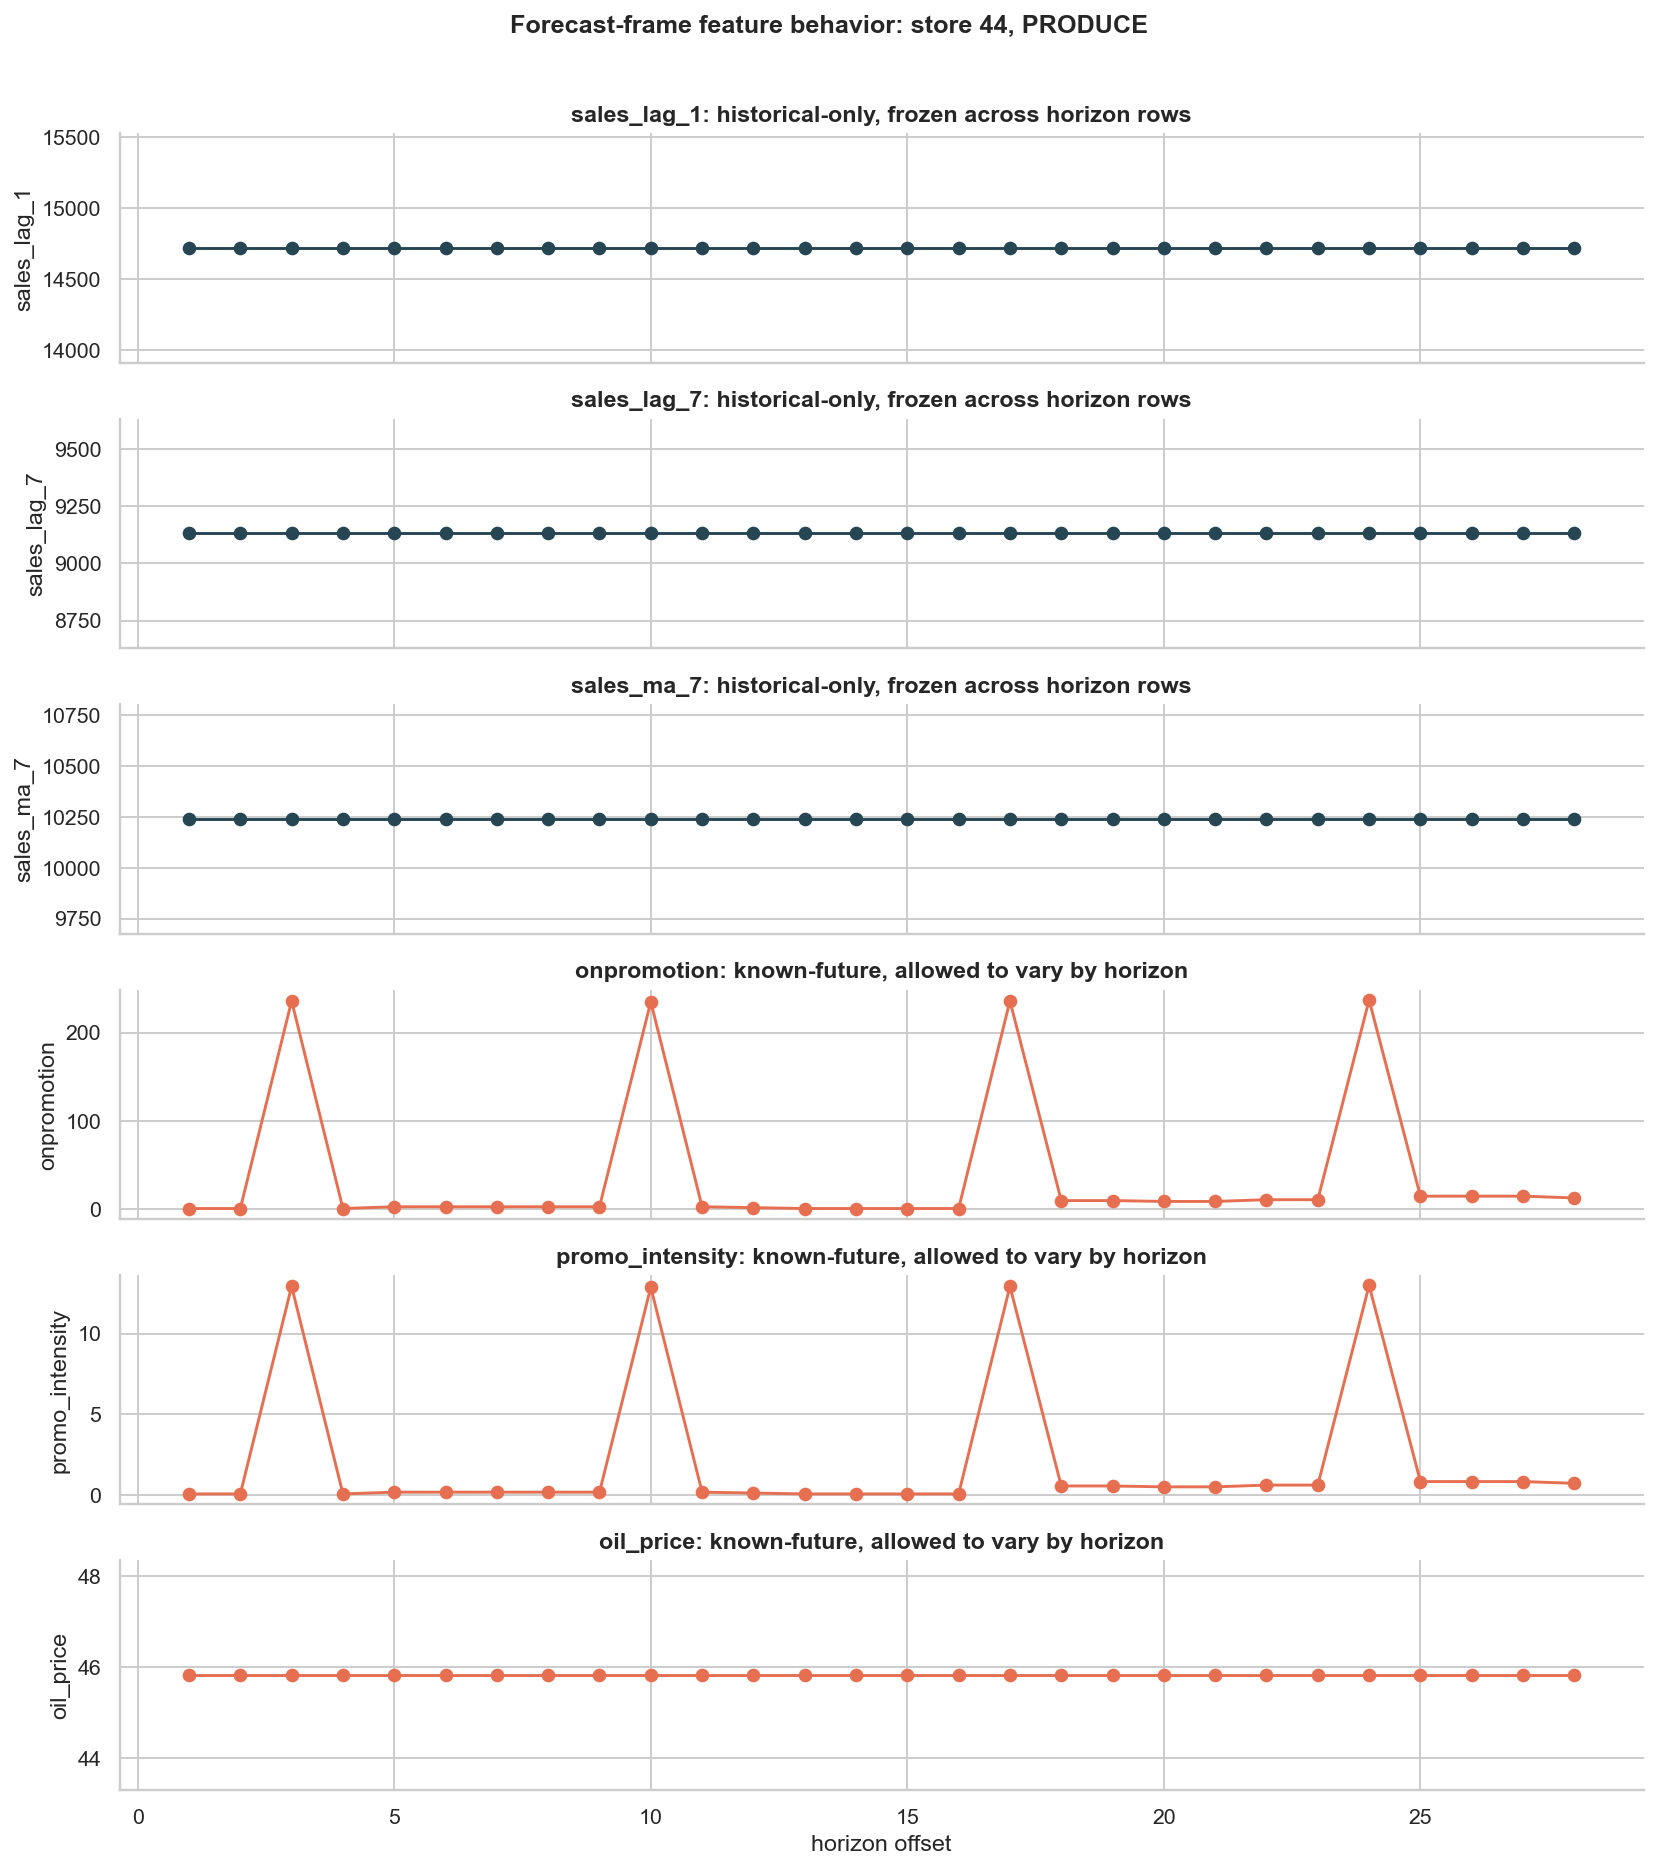

In [38]:
plot_series = examples[0]
store, fam = plot_series
fp = frame_preview[(frame_preview["store_nbr"] == store) & (frame_preview["family"] == fam)].copy()
cols_to_plot = [c for c in ["sales_lag_1", "sales_lag_7", "sales_ma_7", "onpromotion", "promo_intensity", "oil_price"] if c in fp.columns]

fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(12, 2.2 * len(cols_to_plot)), sharex=True)
if len(cols_to_plot) == 1:
    axes = [axes]
for ax, col in zip(axes, cols_to_plot):
    if col in HISTORICAL_ONLY_COLS:
        color, kind = PALETTE["historical"], "historical-only, frozen across horizon rows"
    elif col in KNOWN_FUTURE_COLS:
        color, kind = PALETTE["known_future"], "known-future, allowed to vary by horizon"
    else:
        color, kind = "#666666", ""
    ax.plot(fp["horizon_offset"], fp[col], marker="o", linewidth=1.5, color=color)
    ax.set_ylabel(col)
    ax.set_title(f"{col}: {kind}" if kind else col)
axes[-1].set_xlabel("horizon offset")
fig.suptitle(f"Forecast-frame feature behavior: store {store}, {fam}", y=1.01, fontsize=13, fontweight="bold")
plt.tight_layout()
savefig("09_forecast_frame_feature_behavior.png")
plt.show()

## 12. Lag and Rolling Features on Example Series

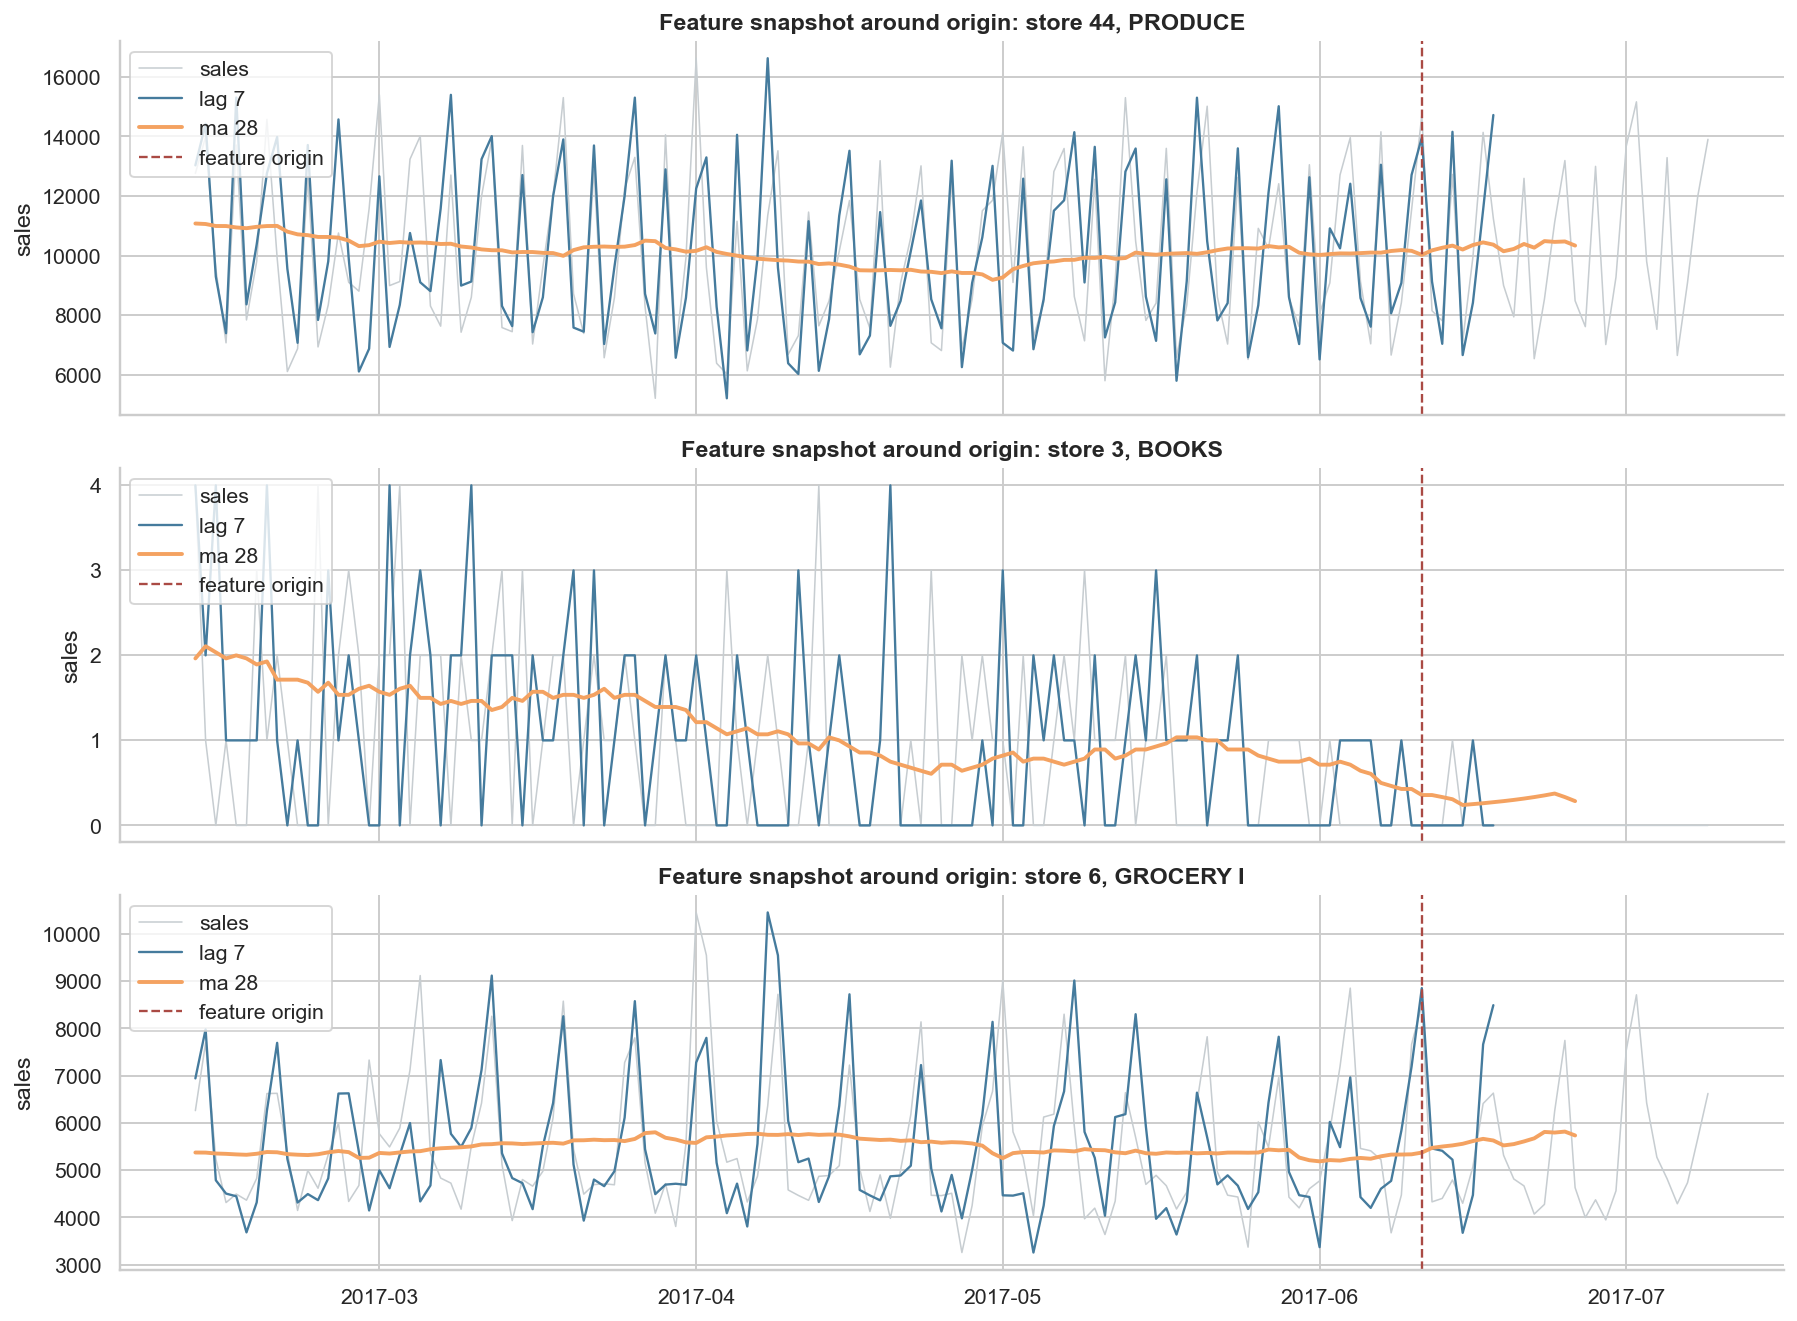

In [47]:
example_filter = pd.DataFrame(examples, columns=["store_nbr", "family"])
example_panel = panel.merge(example_filter, on=["store_nbr", "family"], how="inner")
full_feats = build_features(
    example_panel,
    feature_set="full",
    as_of=feature_origin,
    config=cfg,
    holidays=raw.holidays,
    stores=raw.stores,
)
fig, axes = plt.subplots(len(examples), 1, figsize=(13, 3.2 * len(examples)), sharex=True)
if len(examples) == 1:
    axes = [axes]

for ax, (store, fam) in zip(axes, examples):
    f = full_feats[(full_feats["store_nbr"] == store) & (full_feats["family"] == fam)].sort_values("date")
    window = f[(f["date"] >= feature_origin - pd.Timedelta(days=120)) & (f["date"] <= feature_origin + pd.Timedelta(days=28))]
    ax.plot(window["date"], window["sales"], color="#C7CDD1", linewidth=0.8, label="sales")
    if "sales_lag_7" in window:
        ax.plot(window["date"], window["sales_lag_7"], color="#457B9D", linewidth=1.2, label="lag 7")
    if "sales_ma_28" in window:
        ax.plot(window["date"], window["sales_ma_28"], color=PALETTE["rolling"], linewidth=2, label="ma 28")
    ax.axvline(feature_origin, color="#AA4A44", linestyle="--", linewidth=1.2, label="feature origin")
    ax.set_title(f"Feature snapshot around origin: store {store}, {fam}")
    ax.set_ylabel("sales")
    ax.legend(loc="upper left")
plt.tight_layout()
savefig("10_lag_rolling_feature_snapshots.png")
plt.show()

## 13. Feature Distribution Snapshots

These plots are useful before training: they show skew, sparsity, and why tree models need native missing-value handling.

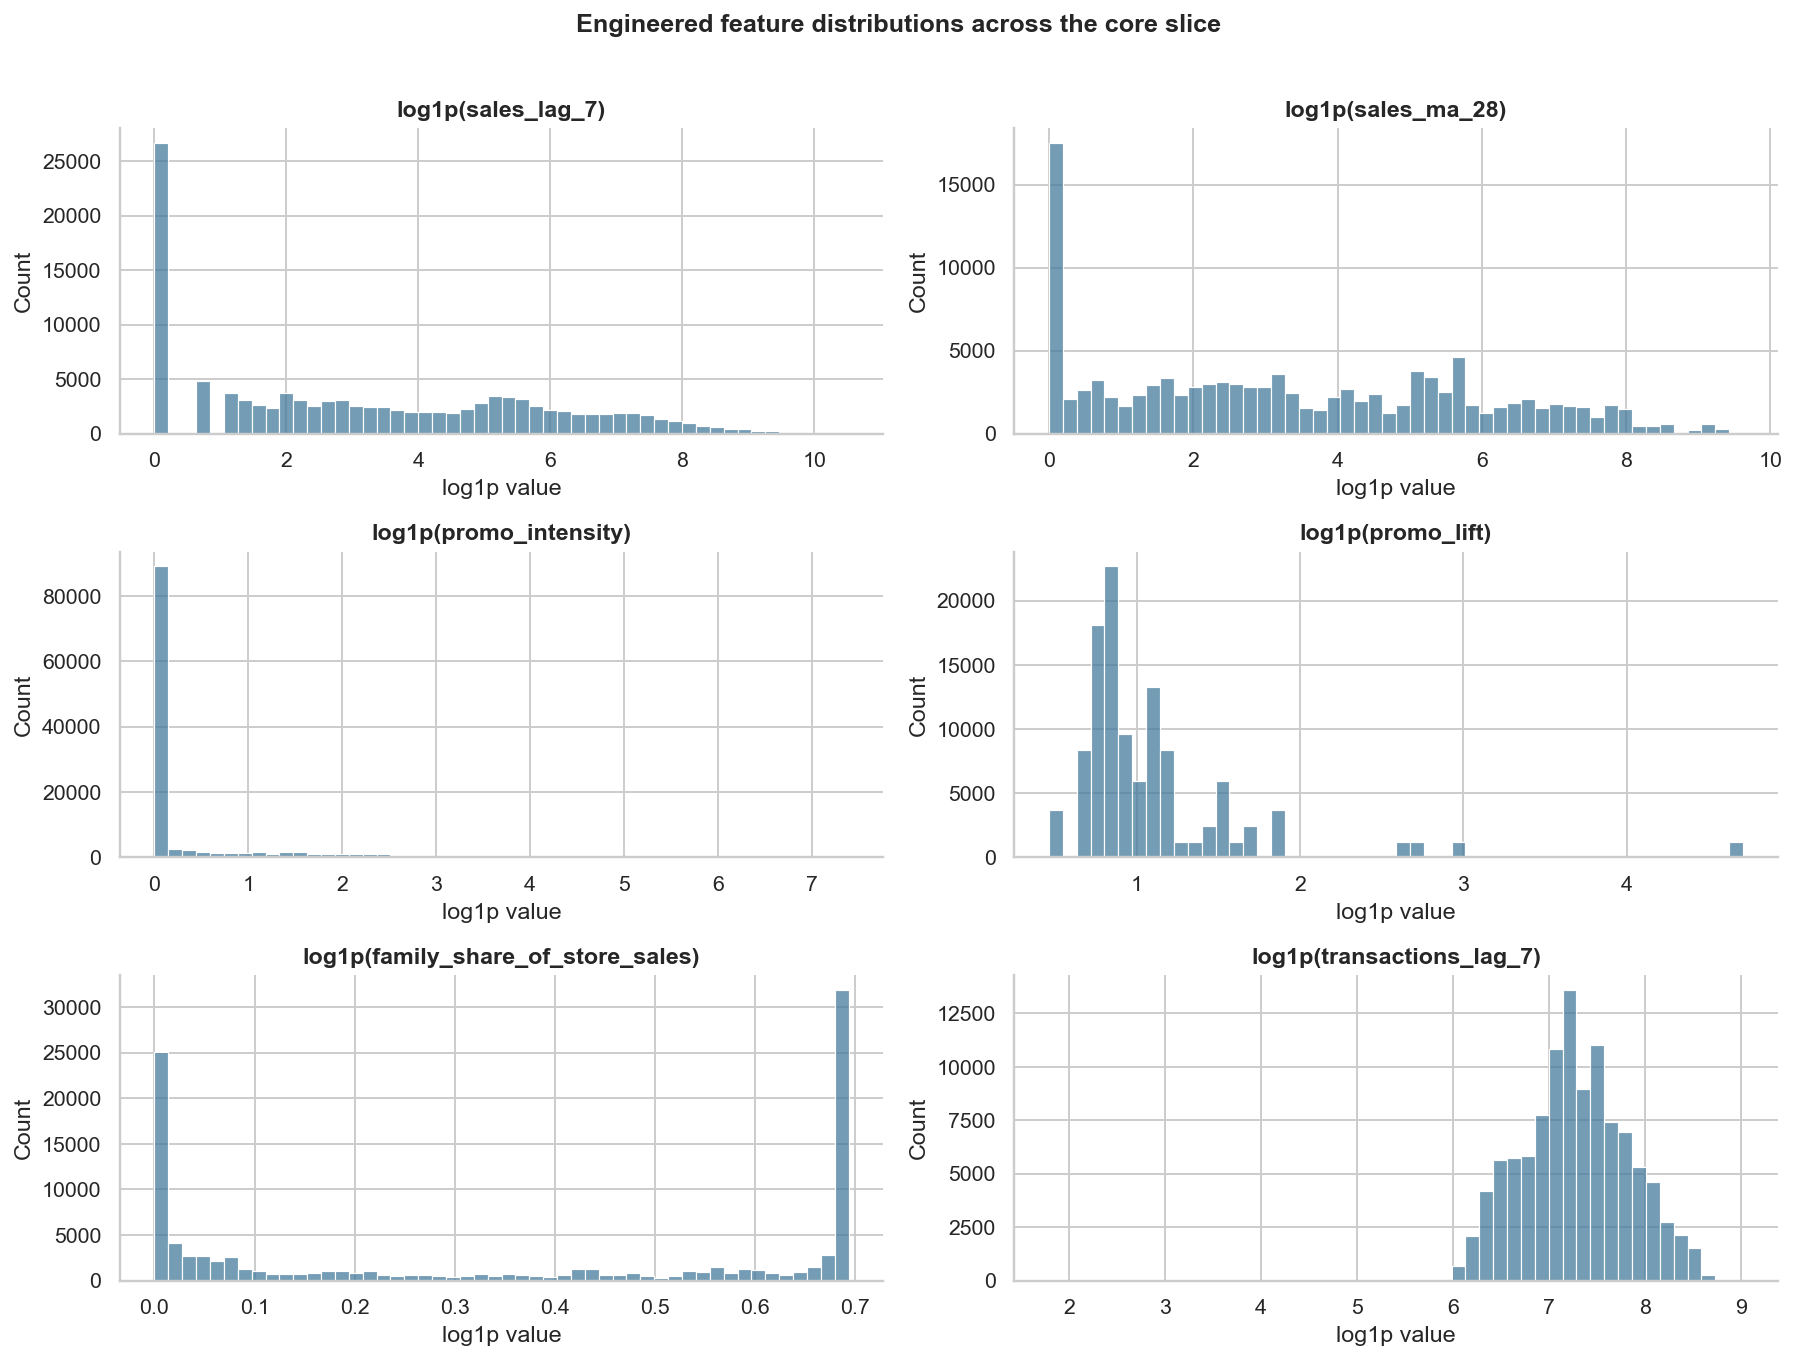

In [48]:
feature_sample = feature_frames["full"].sample(min(120_000, len(feature_frames["full"])), random_state=RANDOM_SEED)
feature_sample["regime"] = feature_sample["family"].map(lambda f: family_regime(f, cfg))
plot_features = [c for c in ["sales_lag_7", "sales_ma_28", "promo_intensity", "promo_lift", "family_share_of_store_sales", "transactions_lag_7"] if c in feature_sample.columns]


def signed_log1p(x: np.ndarray) -> np.ndarray:
    """Symmetric log so we keep the negative tail of features like promo_lift."""
    return np.sign(x) * np.log1p(np.abs(x))


n = len(plot_features)
fig, axes = plt.subplots((n + 1) // 2, 2, figsize=(13, 3.2 * ((n + 1) // 2)))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, plot_features):
    x = feature_sample[col].replace([np.inf, -np.inf], np.nan).dropna()
    if x.empty:
        ax.text(0.5, 0.5, "all missing", ha="center", va="center")
        ax.set_title(col)
        continue
    has_negative = bool((x < 0).any())
    transform = signed_log1p if has_negative else (lambda v: np.log1p(v.clip(lower=0)))
    label_prefix = "signed_log1p" if has_negative else "log1p"
    sns.histplot(transform(x), bins=50, color=PALETTE["oil"], ax=ax)
    ax.set_title(f"{label_prefix}({col})")
    ax.set_xlabel(f"{label_prefix} value")
    if has_negative:
        ax.axvline(0, color="#999999", linewidth=0.8, linestyle=":")
for ax in axes[len(plot_features):]:
    ax.axis("off")
fig.suptitle("Engineered feature distributions across the core slice", y=1.01, fontsize=13, fontweight="bold")
plt.tight_layout()
savefig("11_engineered_feature_distributions.png")
plt.show()

## 14. Takeaways for the Modeling Notebooks

In [41]:
takeaways = pd.DataFrame([
    {"theme": "panel grain", "observation": "modeling uses a complete date x store x family grid", "modeling_implication": "zero-filled train gaps avoid accidental missing series rows"},
    {"theme": "regimes", "observation": "perishable and non-perishable families differ in scale, sparsity, and business horizon", "modeling_implication": "metrics are computed by PRD regime, not only globally"},
    {"theme": "series diversity", "observation": "mean sales and zero-share span orders of magnitude", "modeling_implication": "global models need store/family categoricals and robust missing handling"},
    {"theme": "known future", "observation": "calendar, holidays, oil-forward-fill, and onpromotion are available for forecast rows", "modeling_implication": "supervised frames include horizon-row covariates"},
    {"theme": "historical features", "observation": "lags and rolling features are frozen at the forecast origin", "modeling_implication": "feature ablation tests how much manual history engineering matters"},
])
takeaways

,theme,observation,modeling_implication
0,panel grain,modeling uses a complete date x store x family...,zero-filled train gaps avoid accidental missin...
1,regimes,perishable and non-perishable families differ ...,"metrics are computed by PRD regime, not only g..."
2,series diversity,mean sales and zero-share span orders of magni...,global models need store/family categoricals a...
3,known future,"calendar, holidays, oil-forward-fill, and onpr...",supervised frames include horizon-row covariates
4,historical features,lags and rolling features are frozen at the fo...,feature ablation tests how much manual history...
